In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 63.8 MB/s eta 0:00:00


In [ ]:
import os, random, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks, Model, Input, backend as K
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, matthews_corrcoef,
                             roc_curve, auc, roc_auc_score,
                             classification_report, confusion_matrix)
from concurrent.futures import ThreadPoolExecutor
import shap
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
from io import BytesIO
warnings.filterwarnings('ignore')

#reproducibility and gpu
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"GPU config error: {e}")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    COLAB = True
except:
    COLAB = False

if COLAB:
    DESC_PATH = "/content/drive/MyDrive/descriptors-final.csv"
    FP_PATH   = "/content/drive/MyDrive/fingerprints-final.csv"
    SAVE_DIR  = "/content/drive/MyDrive/models_new/"
else:
    DESC_PATH = "descriptors-final.csv"
    FP_PATH   = "fingerprints-final.csv"
    SAVE_DIR  = "./models/"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
# ================================================================
# 1. DATA LOADING
# ================================================================
print("\n" + "="*60)
print("LOADING & MERGING DATA")
print("="*60)

desc_orig = pd.read_csv(DESC_PATH)
fp_orig   = pd.read_csv(FP_PATH)

print("Descriptor columns:", list(desc_orig.columns))
print("Fingerprint columns:", list(fp_orig.columns))

#common identifiers
possible_keys = ['Molecule ChEMBL ID', 'Smiles']
merge_key = None
for key in possible_keys:
    if key in desc_orig.columns and key in fp_orig.columns:
        merge_key = key
        break

if merge_key is None:
    print("\n WARNING: No common ID column found. Merging on index, assuming identical row order.")
    if len(desc_orig) != len(fp_orig):
        raise ValueError("Descriptor and fingerprint files have different numbers of rows. "
                         "Cannot merge without a common ID column.")
    df = desc_orig.copy()
    fp_copy = fp_orig.copy()
    fp_cols = {c: f"{c}_fp" for c in fp_orig.columns}
    fp_copy.rename(columns=fp_cols, inplace=True)
    df = pd.concat([df.reset_index(drop=True), fp_copy.reset_index(drop=True)], axis=1)
else:
    print(f"Merging on common column: '{merge_key}'")
    df = desc_orig.merge(fp_orig, on=merge_key, how='inner', suffixes=('', '_fp'))

non_desc_cols = ['Molecule ChEMBL ID', 'Smiles', 'Standard value in uM', 'Activity']
desc_feat_cols = [c for c in desc_orig.columns if c not in non_desc_cols]

if merge_key:
    fp_feat_cols = [c for c in fp_orig.columns if c != merge_key]
else:
    fp_feat_cols = [c for c in df.columns if c.endswith('_fp') and c[:-3] in fp_orig.columns]

df.dropna(subset=desc_feat_cols + fp_feat_cols, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Merged dataset size: {len(df)}")

X_desc_raw = df[desc_feat_cols].values.astype(np.float64)
X_fp_raw   = df[fp_feat_cols].values.astype(np.float64)

X_desc_raw = np.where(np.isfinite(X_desc_raw), X_desc_raw, np.nan)
X_fp_raw   = np.where(np.isfinite(X_fp_raw), X_fp_raw, np.nan)
mask = ~np.isnan(X_desc_raw).any(axis=1) & ~np.isnan(X_fp_raw).any(axis=1)
if not mask.all():
    print(f"⚠ Dropping {(~mask).sum()} rows with NaN/Inf after merge")
    X_desc_raw = X_desc_raw[mask]
    X_fp_raw   = X_fp_raw[mask]
    df = df[mask].reset_index(drop=True)

y_raw = df['Activity'].values
if y_raw.dtype == object:
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
else:
    y = y_raw.astype(int)

print(f"Final shape: X_desc={X_desc_raw.shape}, X_fp={X_fp_raw.shape}, y={y.shape}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")


LOADING & MERGING DATA
Descriptor columns: ['Molecule ChEMBL ID', 'Smiles', 'Standard value in uM', 'Activity', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SM

In [ ]:
# ================================================================
# 2. TRAIN/VAL/TEST SPLIT
# ================================================================
print("\n" + "="*60)
print("TRAIN/VAL/TEST SPLIT")
print("="*60)

X_desc_trainval, X_desc_test, X_fp_trainval, X_fp_test, y_trainval, y_test = \
    train_test_split(X_desc_raw, X_fp_raw, y,
                     test_size=0.20, random_state=SEED, stratify=y)

print(f"Train+Val: {len(y_trainval)} samples, Test: {len(y_test)} samples")
print(f"Test class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}")


TRAIN/VAL/TEST SPLIT
Train+Val: 52446 samples, Test: 13112 samples
Test class distribution: {np.int64(0): np.int64(2534), np.int64(1): np.int64(10578)}


In [ ]:
# ================================================================
# 3. HELPERS (IdentityScaler, CosineAnnealing, prep_fold, models)
# ================================================================

class IdentityScaler:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X
    def fit_transform(self, X, y=None):
        return X

class CosineAnnealingScheduler(tf.keras.callbacks.Callback):
    def __init__(self, T_max, eta_min=1e-6):
        super().__init__()
        self.T_max = T_max
        self.eta_min = eta_min

    def on_train_begin(self, logs=None):
        self.initial_lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)

    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self.model.optimizer, 'learning_rate'):
            return
        lr = self.eta_min + 0.5 * (self.initial_lr - self.eta_min) * \
             (1 + np.cos(np.pi * (epoch % self.T_max) / self.T_max))
        self.model.optimizer.learning_rate.assign(lr)

def prep_fold(train_idx, val_idx, X_desc, X_fp, y):
    Xd_tr, Xd_val = X_desc[train_idx], X_desc[val_idx]
    Xf_tr, Xf_val = X_fp[train_idx],   X_fp[val_idx]
    y_tr,  y_val  = y[train_idx],       y[val_idx]

    d_lo, d_hi = np.percentile(Xd_tr, 1, axis=0), np.percentile(Xd_tr, 99, axis=0)
    f_lo, f_hi = np.percentile(Xf_tr, 1, axis=0), np.percentile(Xf_tr, 99, axis=0)

    Xd_tr = np.clip(Xd_tr, d_lo, d_hi)
    Xd_val = np.clip(Xd_val, d_lo, d_hi)
    Xf_tr = np.clip(Xf_tr, f_lo, f_hi)
    Xf_val = np.clip(Xf_val, f_lo, f_hi)

    scaler_desc = StandardScaler()
    scaler_fp   = IdentityScaler()    # no scaling on binary fingerprints

    Xd_tr = scaler_desc.fit_transform(Xd_tr).astype(np.float32)
    Xd_val = scaler_desc.transform(Xd_val).astype(np.float32)
    Xf_tr = scaler_fp.transform(Xf_tr).astype(np.float32)
    Xf_val = scaler_fp.transform(Xf_val).astype(np.float32)

    cw_arr = class_weight.compute_class_weight('balanced',
                                                classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(enumerate(cw_arr))
    return (Xd_tr, Xd_val, Xf_tr, Xf_val, y_tr, y_val, cw_dict,
            scaler_desc, scaler_fp, (d_lo, d_hi), (f_lo, f_hi))

L2 = 1e-4
DROPOUT = 0.3

def build_desc_model(input_dim):
    inp = Input(shape=(input_dim,), name='desc_input')
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='relu', name='desc_penultimate')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = Model(inp, out, name='DescriptorModel')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def build_fp_model(input_dim):
    """Simplified MLP for binary fingerprints – no convolutions."""
    inp = Input(shape=(input_dim,), name='fp_input')
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = Model(inp, out, name='FingerprintModel')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def build_combined_model(desc_dim, fp_dim):
    desc_in = Input(shape=(desc_dim,), name='desc_input')
    fp_in   = Input(shape=(fp_dim,),   name='fp_input')

    d = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(desc_in)
    d = layers.BatchNormalization()(d)
    d = layers.Activation('relu')(d)
    d = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(d)
    d = layers.BatchNormalization()(d)
    d = layers.Activation('relu')(d)
    d_res = layers.add([d, layers.Dense(128)(desc_in)])
    d = layers.Activation('relu')(d_res)
    d = layers.Dropout(DROPOUT)(d)

    f = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(fp_in)
    f = layers.BatchNormalization()(f)
    f = layers.Activation('relu')(f)
    f = layers.Dropout(0.5)(f)
    f = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(f)
    f = layers.BatchNormalization()(f)
    f = layers.Activation('relu')(f)

    gate_input = layers.Concatenate()([d, f])
    gate = layers.Dense(64, activation='relu')(gate_input)
    gate = layers.Dense(2, activation='softmax')(gate)
    d_gated = layers.Multiply()([d, layers.Lambda(lambda g: g[:, 0:1])(gate)])
    f_gated = layers.Multiply()([f, layers.Lambda(lambda g: g[:, 1:2])(gate)])

    concat = layers.Concatenate()([d_gated, f_gated])
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    shortcut = layers.Dense(128)(concat)
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = Model([desc_in, fp_in], out, name='CombinedModel')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def get_callbacks(model_name, fold):
    cp = os.path.join(SAVE_DIR, f'{model_name}_fold{fold}_best.keras')
    return [
        callbacks.EarlyStopping(monitor='val_auc', patience=25,
                                mode='max', restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=50, eta_min=1e-6),
        callbacks.ModelCheckpoint(cp, monitor='val_auc',
                                  save_best_only=True, verbose=0)
    ]

def evaluate(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    return {
        'acc':  accuracy_score(y_true, y_pred),
        'f1':   f1_score(y_true, y_pred, zero_division=0),
        'rec':  recall_score(y_true, y_pred, zero_division=0),
        'prec': precision_score(y_true, y_pred, zero_division=0),
        'mcc':  matthews_corrcoef(y_true, y_pred),
        'auc':  roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0
    }

In [ ]:
# ================================================================
# 4. K‑FOLD CV
# ================================================================
K_FOLDS = 10
print("\n" + "="*60)
print(f"STARTING {K_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(X_desc_trainval, y_trainval))

with ThreadPoolExecutor(max_workers=min(K_FOLDS, 4)) as pool:
    futures = [pool.submit(prep_fold, tr, va, X_desc_trainval, X_fp_trainval, y_trainval)
               for tr, va in splits]
    fold_data = [f.result() for f in futures]

metrics_list = ['acc', 'f1', 'rec', 'prec', 'mcc', 'auc']
results = {m: {met: [] for met in metrics_list} for m in ['desc', 'fp', 'comb']}
best_models = {'desc': [], 'fp': [], 'comb': []}
fold_aucs = {'desc': [], 'fp': [], 'comb': []}
histories = {'desc': [], 'fp': [], 'comb': []}
preprocessing_params = []

BATCH_SIZE, EPOCHS = 256, 100

for fold_num, fold_tuple in enumerate(fold_data, 1):
    (Xd_tr, Xd_val, Xf_tr, Xf_val, y_tr, y_val, cw,
     scaler_desc, scaler_fp, desc_clips, fp_clips) = fold_tuple
    preprocessing_params.append({
        'scaler_desc': scaler_desc,
        'scaler_fp': scaler_fp,
        'desc_clips': desc_clips,
        'fp_clips': fp_clips
    })
    print(f"\n{'='*60}\nFOLD {fold_num}/{K_FOLDS}\n{'='*60}")
    print(f"Train: {len(y_tr)} | Val: {len(y_val)}  Class weights: {cw}")

    #descriptor
    tf.keras.backend.clear_session()
    m_desc = build_desc_model(Xd_tr.shape[1])
    hist_desc = m_desc.fit(Xd_tr, y_tr, validation_data=(Xd_val, y_val),
                           batch_size=BATCH_SIZE, epochs=EPOCHS, class_weight=cw,
                           callbacks=get_callbacks('desc', fold_num), verbose=0)
    prob_desc = m_desc.predict(Xd_val, verbose=0).ravel()
    scores = evaluate(y_val, prob_desc)
    for k, v in scores.items(): results['desc'][k].append(v)
    fold_aucs['desc'].append(scores['auc'])
    best_models['desc'].append(m_desc)
    histories['desc'].append(hist_desc.history)
    print(f"  DESC: AUC={scores['auc']:.4f} MCC={scores['mcc']:.4f} F1={scores['f1']:.4f}")

    #fingerprint
    tf.keras.backend.clear_session()
    m_fp = build_fp_model(Xf_tr.shape[1])
    hist_fp = m_fp.fit(Xf_tr, y_tr, validation_data=(Xf_val, y_val),
                       batch_size=BATCH_SIZE, epochs=EPOCHS, class_weight=cw,
                       callbacks=get_callbacks('fp', fold_num), verbose=0)
    prob_fp = m_fp.predict(Xf_val, verbose=0).ravel()
    scores = evaluate(y_val, prob_fp)
    for k, v in scores.items(): results['fp'][k].append(v)
    fold_aucs['fp'].append(scores['auc'])
    best_models['fp'].append(m_fp)
    histories['fp'].append(hist_fp.history)
    print(f"  FP:   AUC={scores['auc']:.4f} MCC={scores['mcc']:.4f} F1={scores['f1']:.4f}")

    #combined
    tf.keras.backend.clear_session()
    m_comb = build_combined_model(Xd_tr.shape[1], Xf_tr.shape[1])
    hist_comb = m_comb.fit([Xd_tr, Xf_tr], y_tr,
                           validation_data=([Xd_val, Xf_val], y_val),
                           batch_size=BATCH_SIZE, epochs=EPOCHS, class_weight=cw,
                           callbacks=get_callbacks('comb', fold_num), verbose=0)
    prob_comb = m_comb.predict([Xd_val, Xf_val], verbose=0).ravel()
    scores = evaluate(y_val, prob_comb)
    for k, v in scores.items(): results['comb'][k].append(v)
    fold_aucs['comb'].append(scores['auc'])
    best_models['comb'].append(m_comb)
    histories['comb'].append(hist_comb.history)
    print(f"  COMB: AUC={scores['auc']:.4f} MCC={scores['mcc']:.4f} F1={scores['f1']:.4f}")

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (Mean ± Std)")
print("="*60)
for model in ['desc', 'fp', 'comb']:
    print(f"\n{model.upper()}:")
    for metric in metrics_list:
        vals = np.array(results[model][metric])
        print(f"  {metric:4s}: {vals.mean():.4f} ± {vals.std():.4f}")


STARTING 10-FOLD CROSS-VALIDATION

FOLD 1/10
Train: 47201 | Val: 5245  Class weights: {0: np.float64(2.5866396317404647), 1: np.float64(0.6198098589699819)}
Epoch 60: early stopping
Restoring model weights from the end of the best epoch: 35.
  DESC: AUC=0.9196 MCC=0.5938 F1=0.8954
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 16.
  FP:   AUC=0.9220 MCC=0.5963 F1=0.8939
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 12.
  COMB: AUC=0.9245 MCC=0.5942 F1=0.8894

FOLD 2/10
Train: 47201 | Val: 5245  Class weights: {0: np.float64(2.5866396317404647), 1: np.float64(0.6198098589699819)}
Epoch 75: early stopping
Restoring model weights from the end of the best epoch: 50.
  DESC: AUC=0.9117 MCC=0.5793 F1=0.8901
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 21.
  FP:   AUC=0.9237 MCC=0.6002 F1=0.8882
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 24.
  COMB: A

In [ ]:
# ================================================================
# 5. TEST SET EVALUATION (weighted ensemble)
# ================================================================
def ensemble_predict(models, X_desc, X_fp, params, model_type, weights=None):
    preds = []
    for i, (m, p) in enumerate(zip(models, params)):
        d_lo, d_hi = p['desc_clips']
        f_lo, f_hi = p['fp_clips']
        if model_type in ['desc','comb']:
            Xd = np.clip(X_desc, d_lo, d_hi)
            Xd = p['scaler_desc'].transform(Xd).astype(np.float32)
        if model_type in ['fp','comb']:
            Xf = np.clip(X_fp, f_lo, f_hi)
            Xf = p['scaler_fp'].transform(Xf).astype(np.float32)

        if model_type == 'desc':
            pred = m.predict(Xd, verbose=0).ravel()
        elif model_type == 'fp':
            pred = m.predict(Xf, verbose=0).ravel()
        else:
            pred = m.predict([Xd, Xf], verbose=0).ravel()
        preds.append(pred)
    preds = np.stack(preds, axis=0)
    if weights is not None:
        weights = np.array(weights)
        weights /= weights.sum()
        return np.average(preds, axis=0, weights=weights)
    return np.mean(preds, axis=0)

print("\n" + "="*60)
print("TEST SET EVALUATION (WEIGHTED ENSEMBLE)")
print("="*60)

test_results = {}
test_probs = {}
test_preds = {}
for mtype in ['desc', 'fp', 'comb']:
    weights = np.maximum(fold_aucs[mtype], 0.5)
    prob = ensemble_predict(best_models[mtype],
                            X_desc_test, X_fp_test,
                            preprocessing_params, mtype,
                            weights=weights)
    pred = (prob > 0.5).astype(int)
    test_probs[mtype] = prob
    test_preds[mtype] = pred
    metrics = evaluate(y_test, prob)
    test_results[mtype] = metrics
    print(f"\n{mtype.upper()}:")
    for k, v in metrics.items():
        print(f"  {k:4s}: {v:.4f}")

test_df = pd.DataFrame([{**{'Model': k.upper()}, **v} for k,v in test_results.items()])
test_df.to_csv(os.path.join(SAVE_DIR, 'test_results.csv'), index=False)


TEST SET EVALUATION (WEIGHTED ENSEMBLE)

DESC:
  acc : 0.8464
  f1  : 0.8991
  rec : 0.8484
  prec: 0.9563
  mcc : 0.6010
  auc : 0.9241

FP:
  acc : 0.8485
  f1  : 0.9003
  rec : 0.8479
  prec: 0.9596
  mcc : 0.6098
  auc : 0.9324

COMB:
  acc : 0.8529
  f1  : 0.9036
  rec : 0.8543
  prec: 0.9588
  mcc : 0.6158
  auc : 0.9345



GENERATING PLOTS


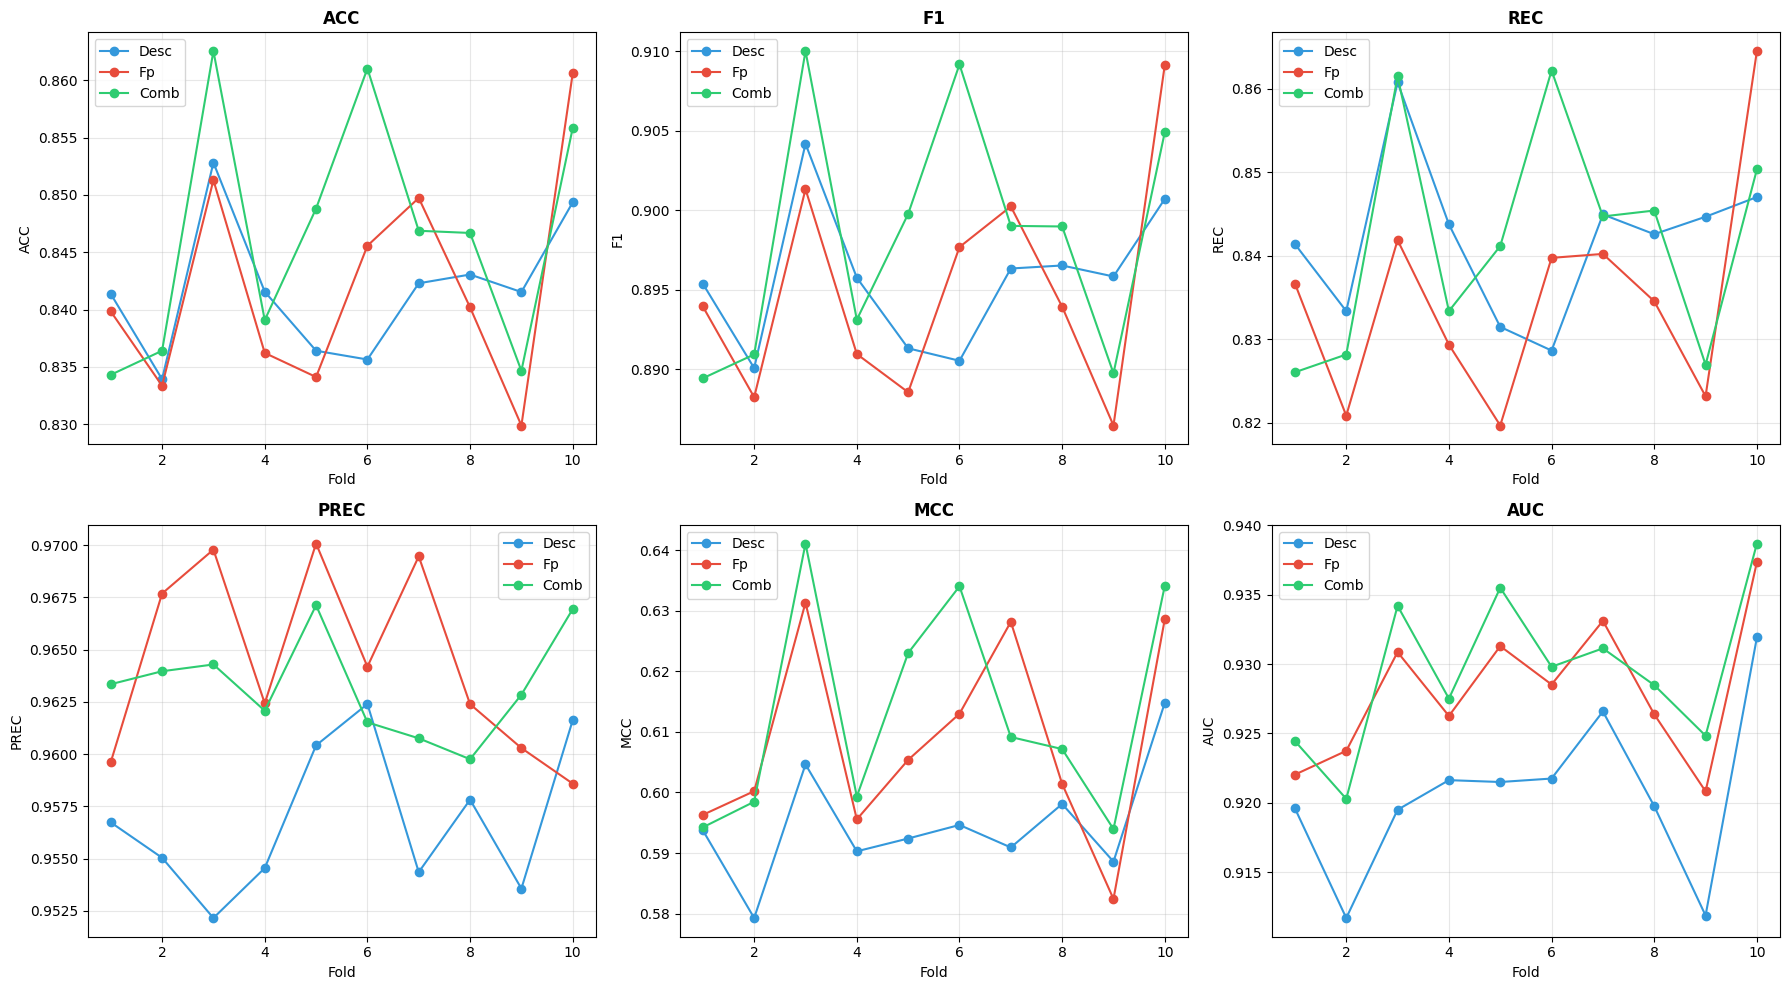

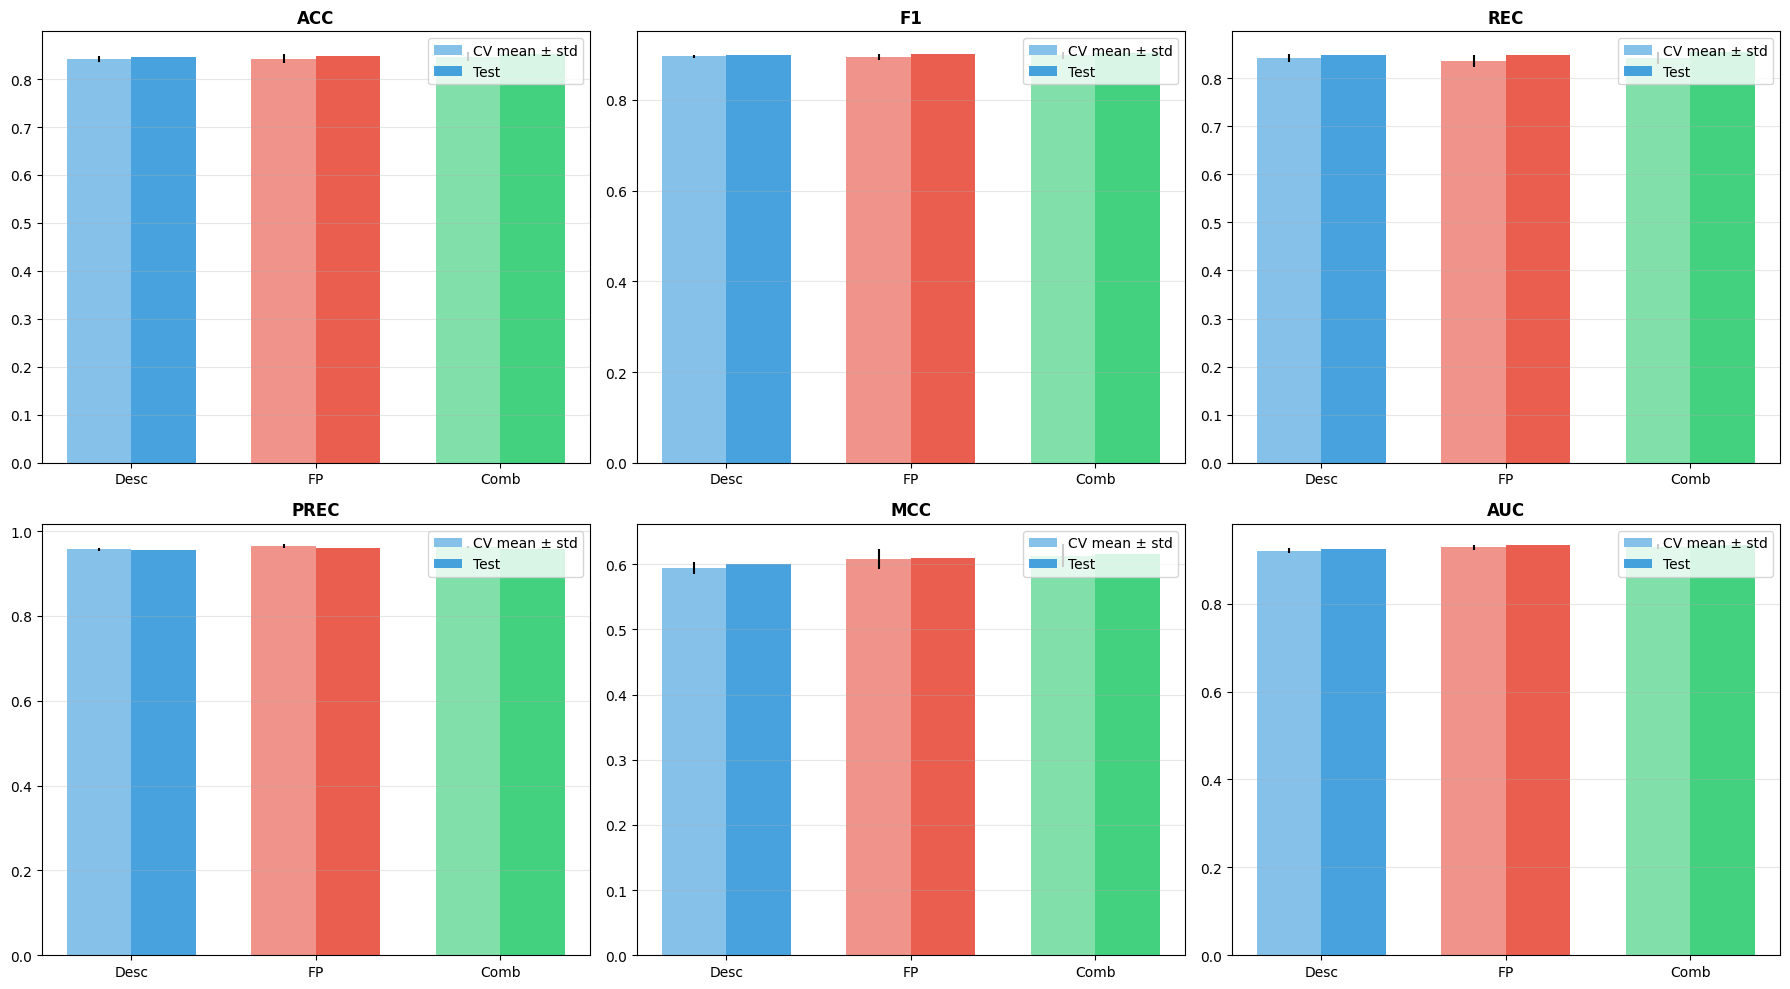

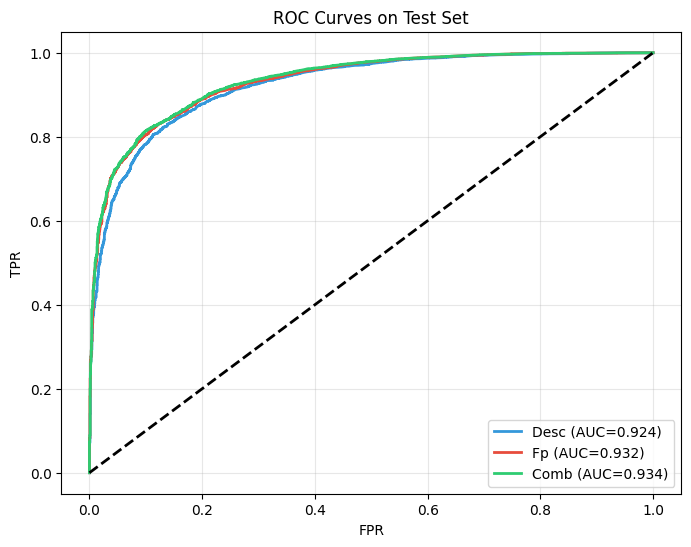

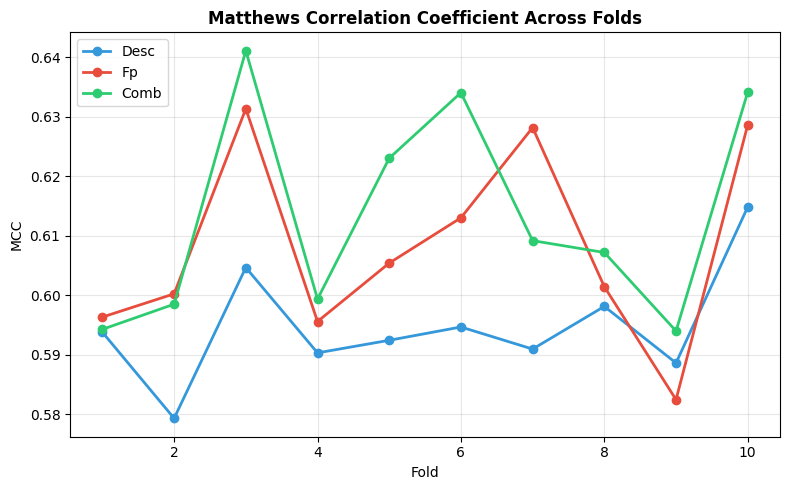

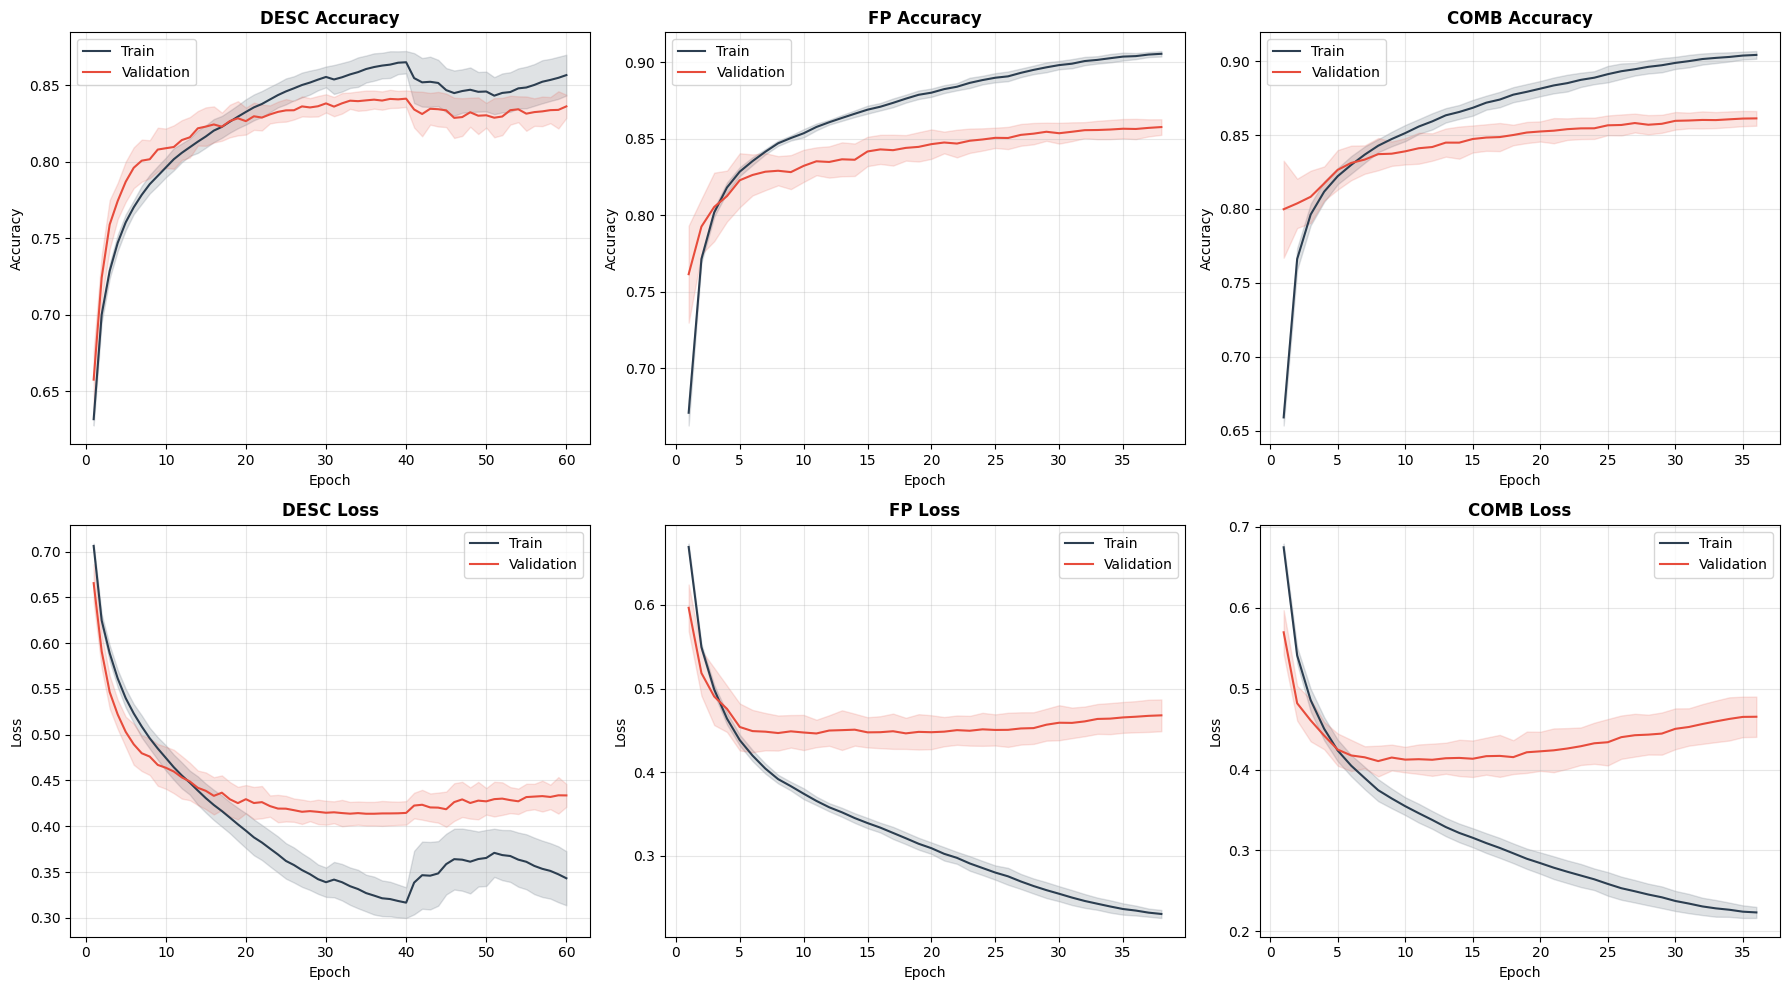

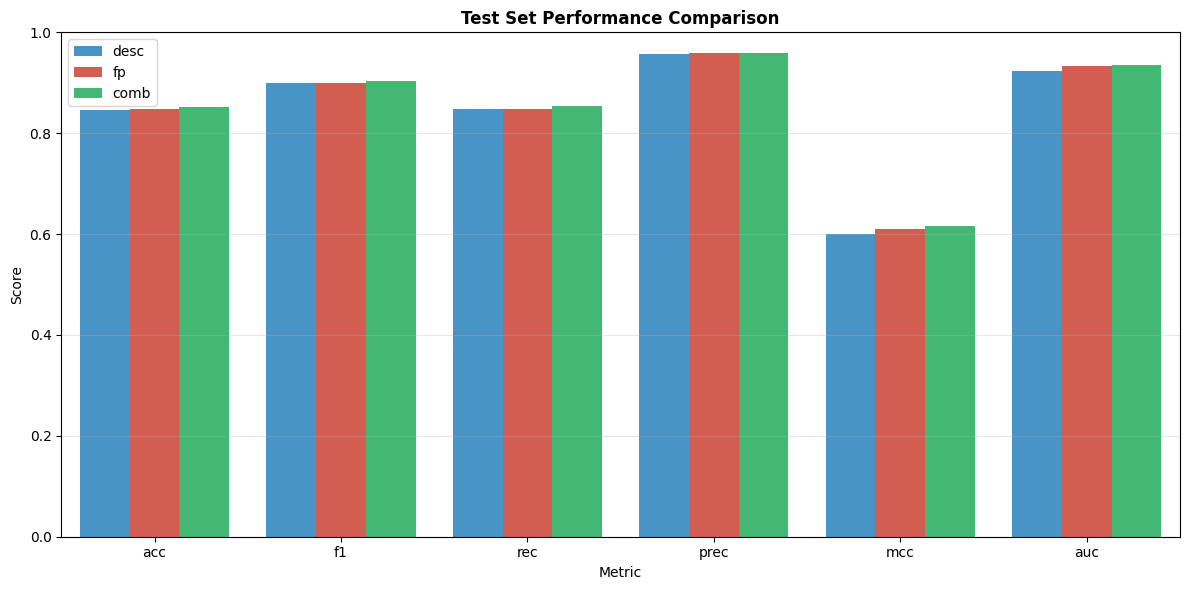

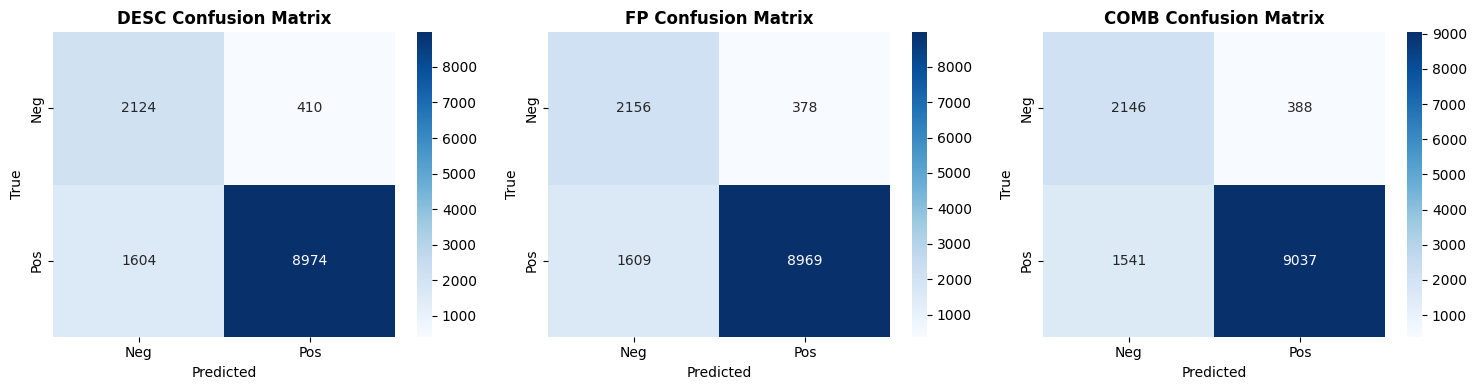

In [ ]:
# ================================================================
# 6. PLOTS (all extended graphs)
# ================================================================
def plot_cv_metrics():
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.ravel()
    folds = range(1, K_FOLDS+1)
    colors = {'desc':'#3498db', 'fp':'#e74c3c', 'comb':'#2ecc71'}
    for idx, metric in enumerate(metrics_list):
        ax = axes[idx]
        for model in ['desc','fp','comb']:
            ax.plot(folds, results[model][metric], marker='o',
                    color=colors[model], label=model.capitalize())
        ax.set_title(metric.upper(), fontweight='bold')
        ax.set_xlabel('Fold')
        ax.set_ylabel(metric.upper())
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'cv_metrics.png'), dpi=300)
    plt.show()

def plot_cv_vs_test():
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.ravel()
    x_pos = np.arange(3)
    colors = {'desc':'#3498db','fp':'#e74c3c','comb':'#2ecc71'}
    for idx, metric in enumerate(metrics_list):
        ax = axes[idx]
        cv_means = [np.mean(results[m][metric]) for m in ['desc','fp','comb']]
        cv_stds  = [np.std(results[m][metric]) for m in ['desc','fp','comb']]
        test_vals= [test_results[m][metric] for m in ['desc','fp','comb']]
        w = 0.35
        ax.bar(x_pos - w/2, cv_means, w, yerr=cv_stds, label='CV mean ± std',
               color=[colors[m] for m in ['desc','fp','comb']], alpha=0.6)
        ax.bar(x_pos + w/2, test_vals, w, label='Test',
               color=[colors[m] for m in ['desc','fp','comb']], alpha=0.9)
        ax.set_title(metric.upper(), fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Desc','FP','Comb'])
        ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'cv_vs_test.png'), dpi=300)
    plt.show()

def plot_test_roc():
    plt.figure(figsize=(8,6))
    colors = {'desc':'#3498db','fp':'#e74c3c','comb':'#2ecc71'}
    for mtype in ['desc','fp','comb']:
        fpr, tpr, _ = roc_curve(y_test, test_probs[mtype])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[mtype], lw=2,
                 label=f'{mtype.capitalize()} (AUC={roc_auc:.3f})')
    plt.plot([0,1],[0,1],'k--', lw=2)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('ROC Curves on Test Set')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(SAVE_DIR, 'test_roc.png'), dpi=300)
    plt.show()

def plot_per_fold_mcc():
    plt.figure(figsize=(8,5))
    folds = range(1, K_FOLDS+1)
    colors = {'desc':'#3498db', 'fp':'#e74c3c', 'comb':'#2ecc71'}
    for model in ['desc','fp','comb']:
        plt.plot(folds, results[model]['mcc'], marker='o', linewidth=2,
                 color=colors[model], label=model.capitalize())
    plt.title('Matthews Correlation Coefficient Across Folds', fontweight='bold')
    plt.xlabel('Fold'); plt.ylabel('MCC')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'cv_mcc.png'), dpi=300)
    plt.show()

def plot_learning_curves():
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.ravel()
    models = ['desc', 'fp', 'comb']
    for i, model in enumerate(models):
        hist_list = histories[model]
        min_len = min(len(h['loss']) for h in hist_list)
        trn_acc = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['accuracy'])), h['accuracy'])
                           for h in hist_list])
        val_acc = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['val_accuracy'])), h['val_accuracy'])
                           for h in hist_list])
        trn_loss = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['loss'])), h['loss'])
                            for h in hist_list])
        val_loss = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['val_loss'])), h['val_loss'])
                            for h in hist_list])
        epochs = np.arange(1, min_len+1)

        ax_acc = axes[i]
        ax_acc.plot(epochs, trn_acc.mean(axis=0), color='#2c3e50', label='Train')
        ax_acc.fill_between(epochs,
                            trn_acc.mean(axis=0) - trn_acc.std(axis=0),
                            trn_acc.mean(axis=0) + trn_acc.std(axis=0),
                            color='#2c3e50', alpha=0.15)
        ax_acc.plot(epochs, val_acc.mean(axis=0), color='#e74c3c', label='Validation')
        ax_acc.fill_between(epochs,
                            val_acc.mean(axis=0) - val_acc.std(axis=0),
                            val_acc.mean(axis=0) + val_acc.std(axis=0),
                            color='#e74c3c', alpha=0.15)
        ax_acc.set_title(f'{model.upper()} Accuracy', fontweight='bold')
        ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
        ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

        ax_loss = axes[i+3]
        ax_loss.plot(epochs, trn_loss.mean(axis=0), color='#2c3e50', label='Train')
        ax_loss.fill_between(epochs,
                             trn_loss.mean(axis=0) - trn_loss.std(axis=0),
                             trn_loss.mean(axis=0) + trn_loss.std(axis=0),
                             color='#2c3e50', alpha=0.15)
        ax_loss.plot(epochs, val_loss.mean(axis=0), color='#e74c3c', label='Validation')
        ax_loss.fill_between(epochs,
                             val_loss.mean(axis=0) - val_loss.std(axis=0),
                             val_loss.mean(axis=0) + val_loss.std(axis=0),
                             color='#e74c3c', alpha=0.15)
        ax_loss.set_title(f'{model.upper()} Loss', fontweight='bold')
        ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
        ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'learning_curves.png'), dpi=300)
    plt.show()

def plot_model_comparison():
    df_metrics = pd.DataFrame(test_results).T.reset_index().rename(columns={'index':'Model'})
    df_metrics = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
    plt.figure(figsize=(12,6))
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model',
                palette={'desc':'#3498db','fp':'#e74c3c','comb':'#2ecc71'})
    plt.title('Test Set Performance Comparison', fontweight='bold')
    plt.ylim(0,1)
    plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'model_comparison.png'), dpi=300)
    plt.show()

def plot_confusion_matrices():
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    models = ['desc','fp','comb']
    for i, mtype in enumerate(models):
        cm = confusion_matrix(y_test, test_preds[mtype])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[i].set_title(f'{mtype.upper()} Confusion Matrix', fontweight='bold')
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices.png'), dpi=300)
    plt.show()

print("\n" + "="*60)
print("GENERATING PLOTS")
print("="*60)
plot_cv_metrics()
plot_cv_vs_test()
plot_test_roc()
plot_per_fold_mcc()
plot_learning_curves()
plot_model_comparison()
plot_confusion_matrices()


SHAP ANALYSIS – COMBINED MODEL
Computing SHAP values for 60 test samples (nsamples=200)...


  0%|          | 0/60 [00:00<?, ?it/s]

Active (non-zero) SHAP features: 451 / 2265


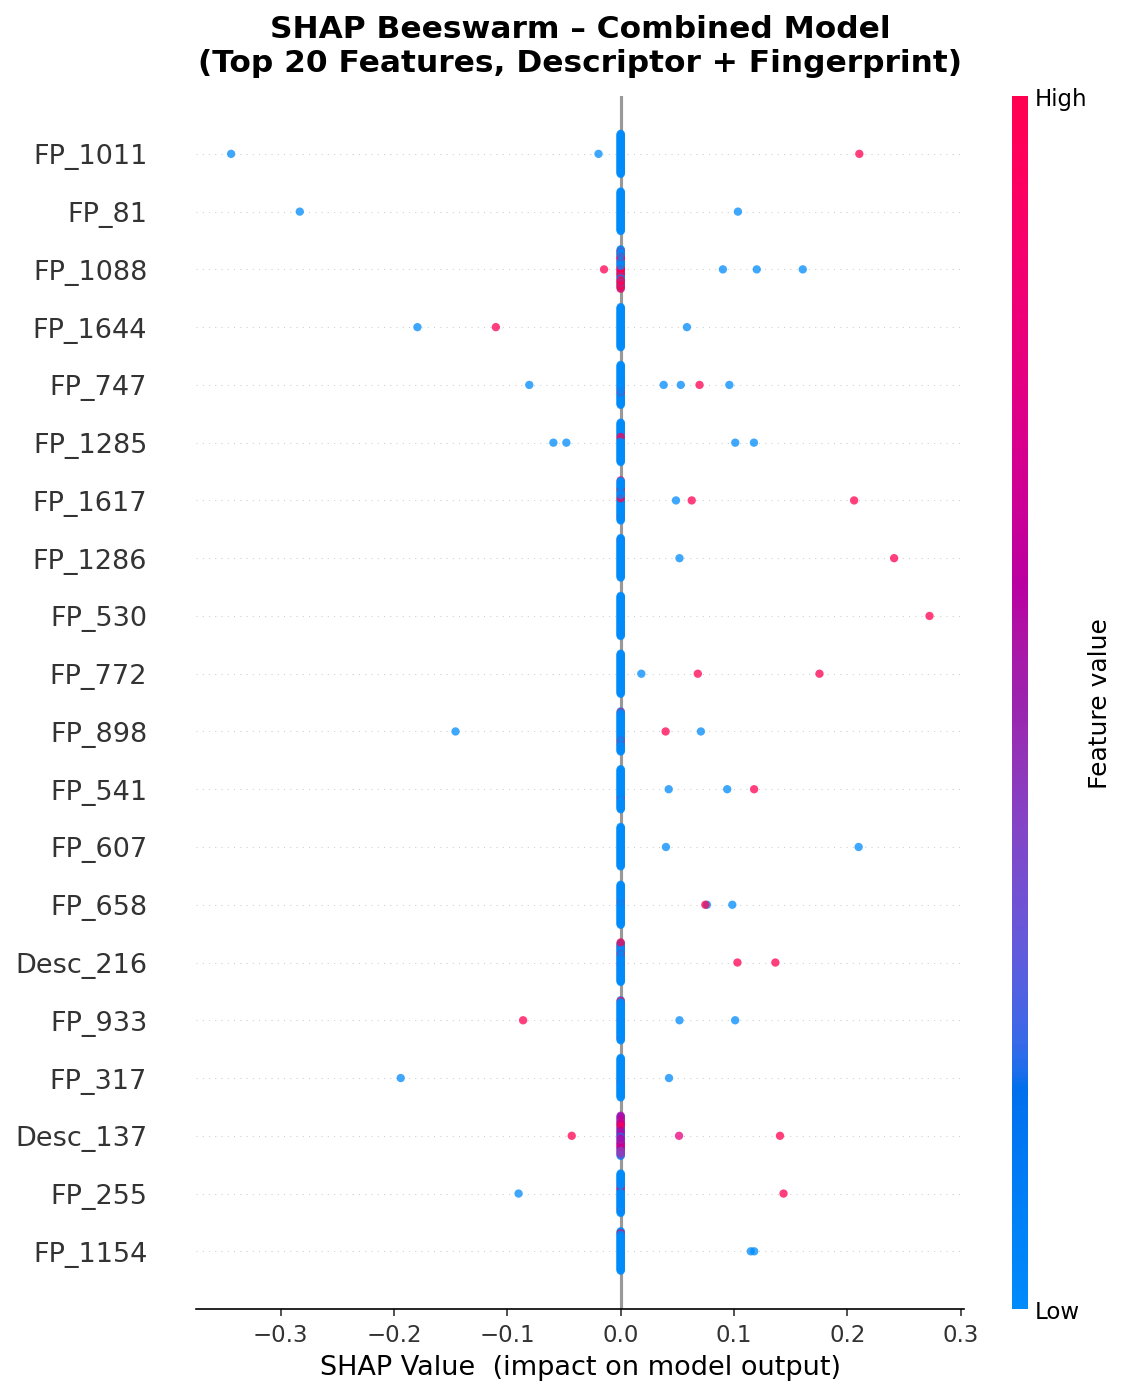

Saved: shap_combined_summary.png


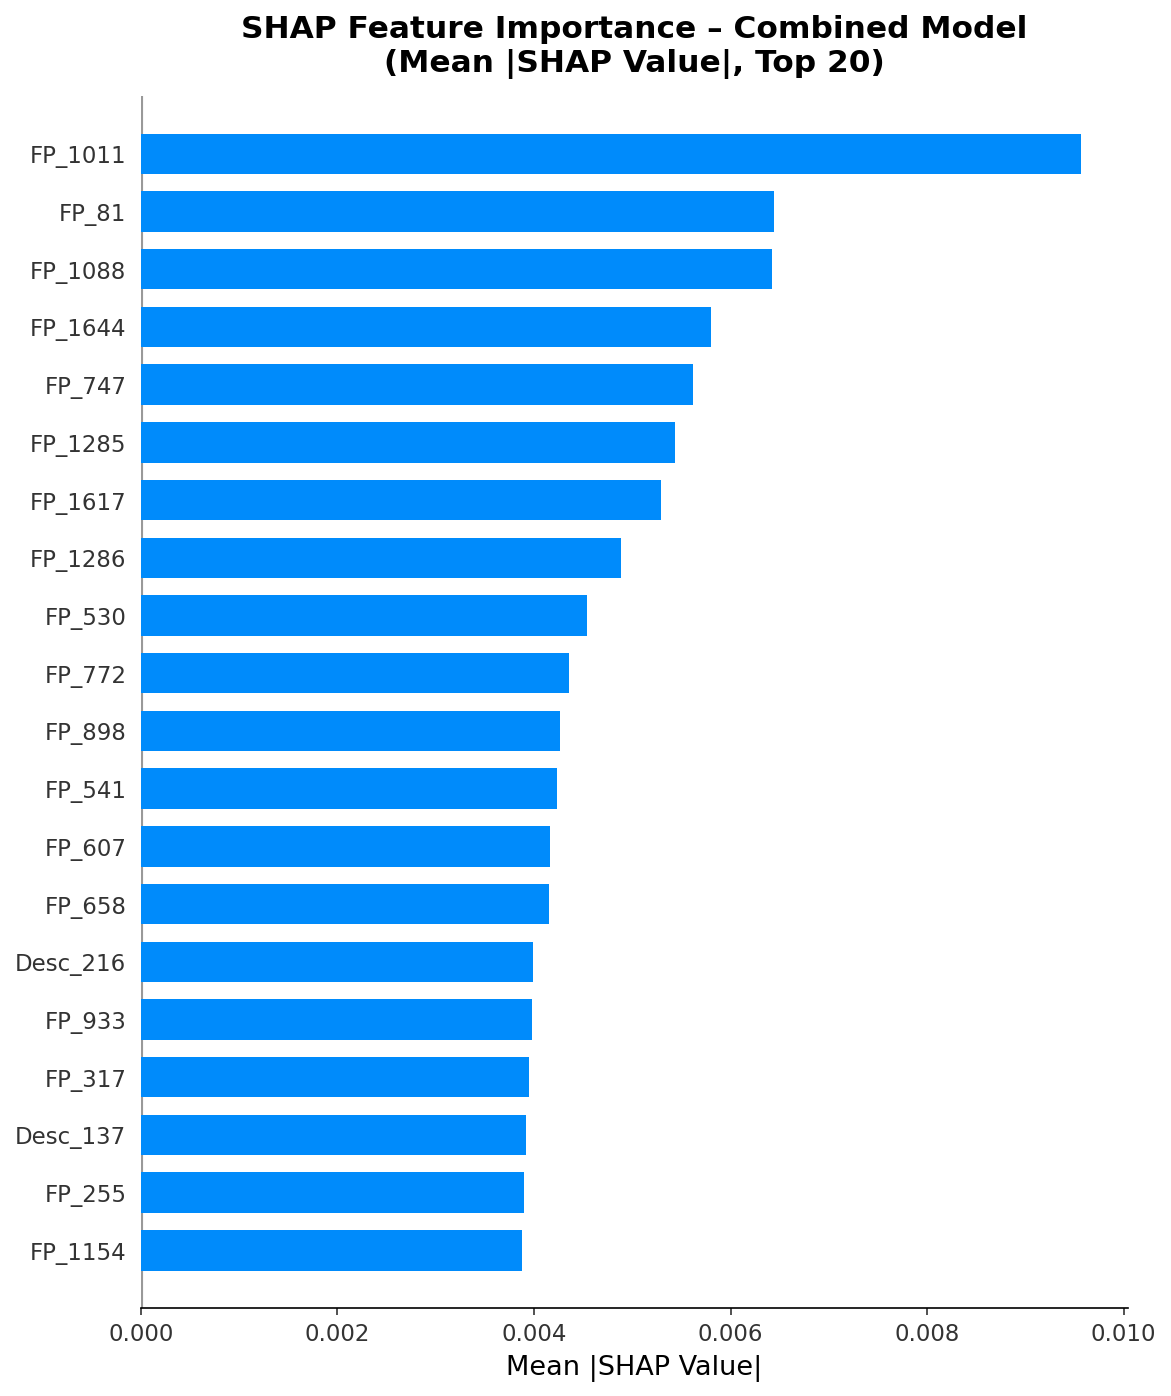

Saved: shap_combined_bar.png


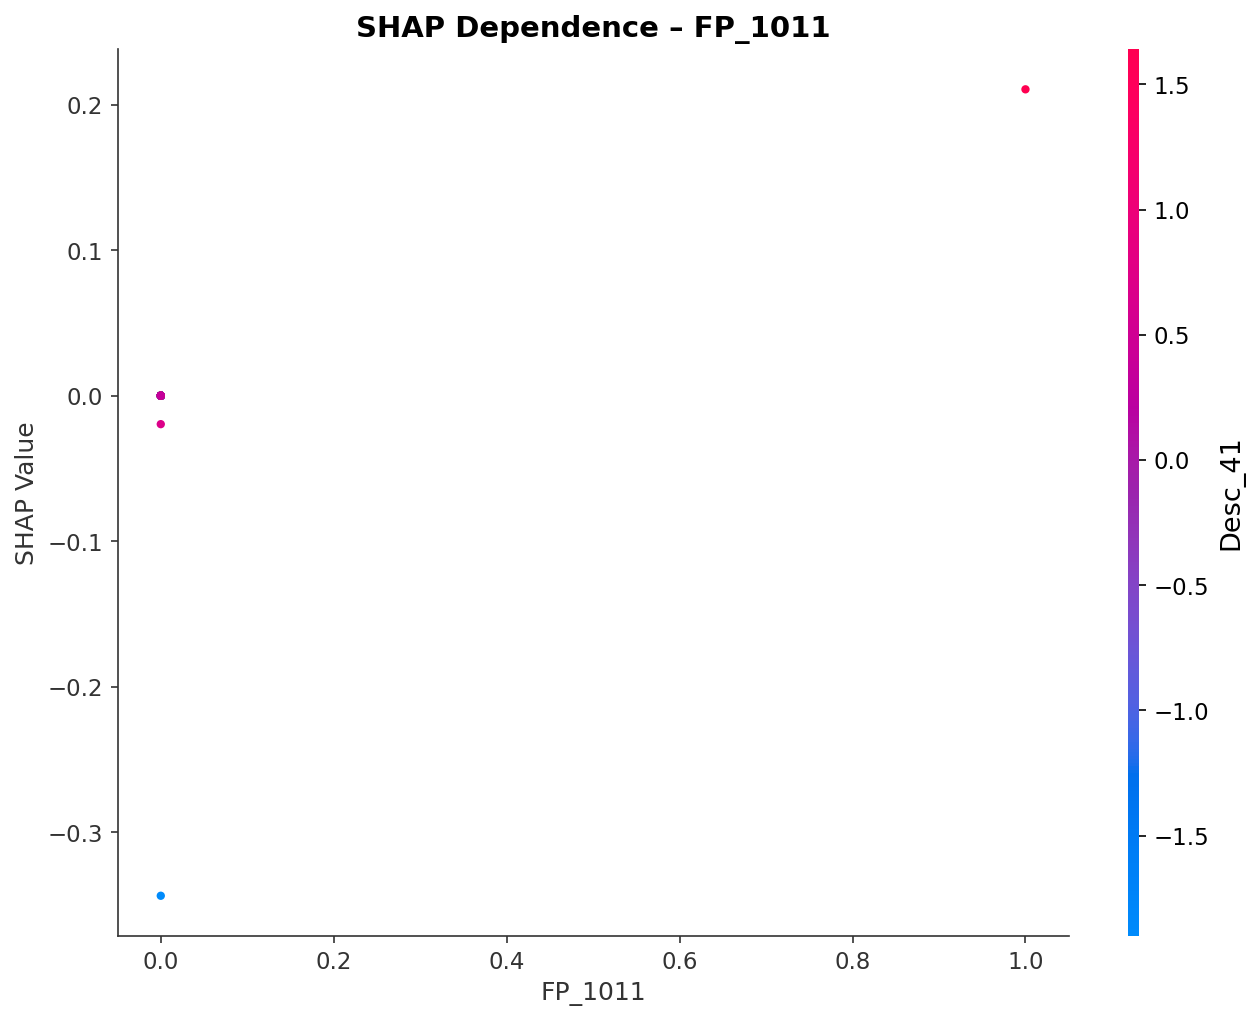

Saved: shap_dependence_comb.png


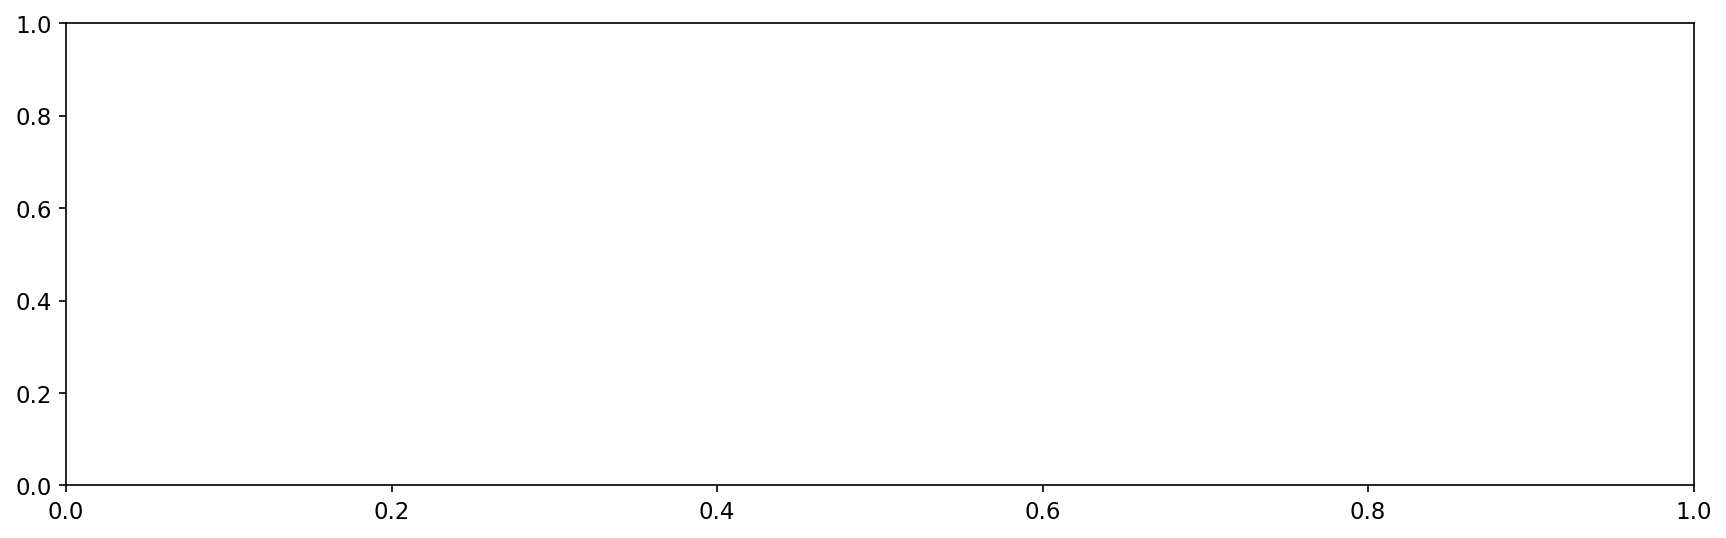

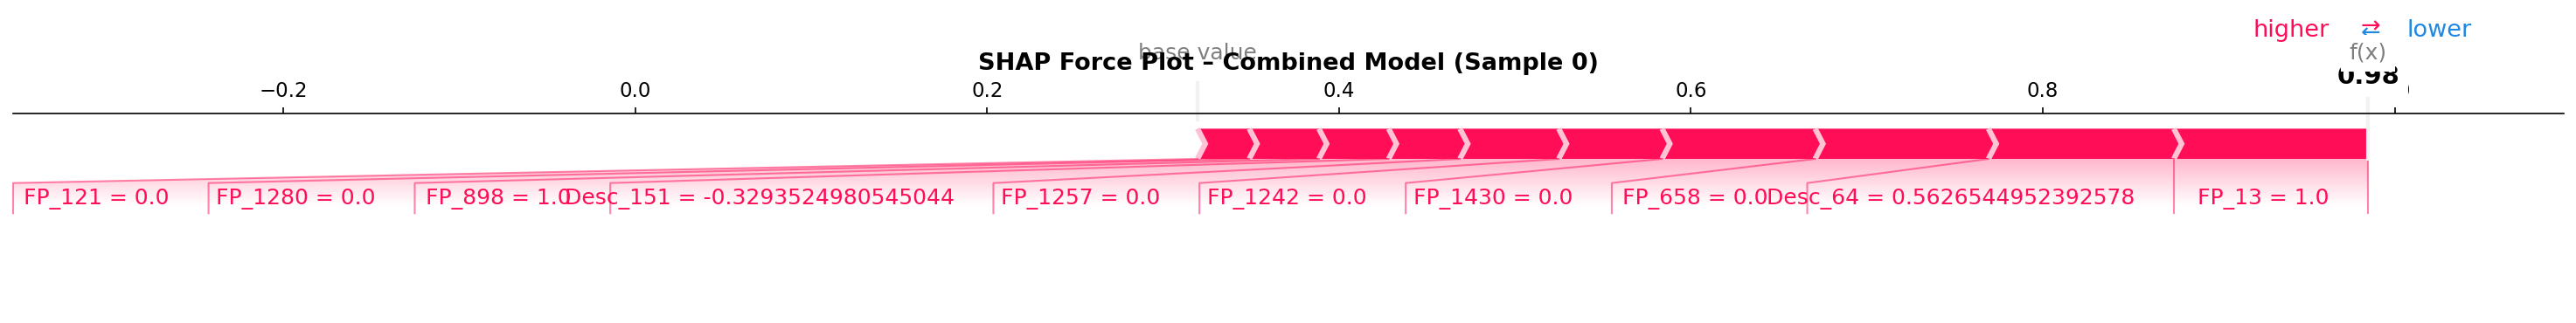

Saved: shap_force_comb.png

Top 20 Combined Features:
 Feature  Mean_Abs_SHAP
 FP_1011       0.009565
   FP_81       0.006443
 FP_1088       0.006426
 FP_1644       0.005799
  FP_747       0.005617
 FP_1285       0.005433
 FP_1617       0.005290
 FP_1286       0.004885
  FP_530       0.004542
  FP_772       0.004361
  FP_898       0.004269
  FP_541       0.004234
  FP_607       0.004164
  FP_658       0.004155
Desc_216       0.003991
  FP_933       0.003983
  FP_317       0.003945
Desc_137       0.003920
  FP_255       0.003896
 FP_1154       0.003876


In [ ]:
# ================================================================
# 7. SHAP EXPLAINABILITY – COMBINED MODEL
# ================================================================
print("\n" + "="*60)
print("SHAP ANALYSIS – COMBINED MODEL")
print("="*60)

import matplotlib
matplotlib.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'font.family': 'DejaVu Sans', 'figure.dpi': 150,
})

first_params    = preprocessing_params[0]
scaler_desc_shap = first_params['scaler_desc']
scaler_fp_shap   = first_params['scaler_fp']
d_lo, d_hi       = first_params['desc_clips']
f_lo, f_hi       = first_params['fp_clips']

X_desc_test_clipped = np.clip(X_desc_test, d_lo, d_hi)
X_fp_test_clipped   = np.clip(X_fp_test,   f_lo, f_hi)
X_desc_test_shap = scaler_desc_shap.transform(X_desc_test_clipped).astype(np.float32)
X_fp_test_shap   = scaler_fp_shap.transform(X_fp_test_clipped).astype(np.float32)

Xd_bg_pool = np.clip(X_desc_trainval[:1000], d_lo, d_hi)
Xf_bg_pool = np.clip(X_fp_trainval[:1000],   f_lo, f_hi)
Xd_bg_pool = scaler_desc_shap.transform(Xd_bg_pool).astype(np.float32)
Xf_bg_pool = scaler_fp_shap.transform(Xf_bg_pool).astype(np.float32)

Xd_bg_mean = Xd_bg_pool.mean(axis=0, keepdims=True)
Xf_bg_mean = Xf_bg_pool.mean(axis=0, keepdims=True)
X_bg_comb  = np.hstack([Xd_bg_mean, Xf_bg_mean])

m_comb_shap = best_models['comb'][0]

def predict_fn_comb(X):
    split = X_desc_test_shap.shape[1]
    return m_comb_shap.predict([X[:, :split], X[:, split:]], verbose=0).ravel()

explainer_comb = shap.KernelExplainer(predict_fn_comb, X_bg_comb)

n_sample   = min(60, len(X_desc_test_shap))
np.random.seed(42)
idx_sample = np.random.choice(len(X_desc_test_shap), n_sample, replace=False)
X_sample   = np.hstack([X_desc_test_shap[idx_sample], X_fp_test_shap[idx_sample]])

print(f"Computing SHAP values for {n_sample} test samples (nsamples=200)...")
shap_values_comb = explainer_comb.shap_values(X_sample, nsamples=200)

feature_names_comb = (
    [f"Desc_{i}" for i in range(X_desc_test_shap.shape[1])] +
    [f"FP_{i}"   for i in range(X_fp_test_shap.shape[1])]
)

shap_std   = np.abs(shap_values_comb).max(axis=0)
active_idx = np.where(shap_std > 1e-8)[0]
print(f"Active (non-zero) SHAP features: {len(active_idx)} / {shap_values_comb.shape[1]}")

shap_active       = shap_values_comb[:, active_idx]
X_sample_active   = X_sample[:, active_idx]
names_active      = [feature_names_comb[i] for i in active_idx]

#Beeswarm / Summary plot
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_active, X_sample_active,
                  feature_names=names_active,
                  max_display=20, show=False, alpha=0.75)
ax = plt.gca()
ax.set_title("SHAP Beeswarm – Combined Model\n(Top 20 Features, Descriptor + Fingerprint)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("SHAP Value  (impact on model output)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_combined_summary.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_combined_summary.png")

#Bar plot (mean |SHAP|)
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_active, X_sample_active,
                  feature_names=names_active,
                  plot_type='bar', max_display=20, show=False)
ax = plt.gca()
ax.set_title("SHAP Feature Importance – Combined Model\n(Mean |SHAP Value|, Top 20)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("Mean |SHAP Value|", fontsize=13)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_combined_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_combined_bar.png")

#Dependence plot (top feature)
mean_abs_shap_comb = np.abs(shap_active).mean(axis=0)
top_local_idx      = int(np.argmax(mean_abs_shap_comb))
fig, ax = plt.subplots(figsize=(9, 7))
shap.dependence_plot(top_local_idx, shap_active, X_sample_active,
                     feature_names=names_active, show=False, ax=ax)
ax.set_title(f"SHAP Dependence – {names_active[top_local_idx]}",
             fontsize=14, fontweight='bold')
ax.set_xlabel(names_active[top_local_idx], fontsize=12)
ax.set_ylabel("SHAP Value", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_dependence_comb.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_comb.png")

#Force plot (first sample)
fig, ax = plt.subplots(figsize=(14, 4))
shap.force_plot(explainer_comb.expected_value,
                shap_active[0, :], X_sample_active[0, :],
                feature_names=names_active,
                matplotlib=True, show=False)
plt.title("SHAP Force Plot – Combined Model (Sample 0)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_force_comb.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_force_comb.png")

#Save importance table
feat_imp_comb = pd.DataFrame({
    'Feature': names_active,
    'Mean_Abs_SHAP': mean_abs_shap_comb
}).sort_values('Mean_Abs_SHAP', ascending=False)
feat_imp_comb.to_csv(os.path.join(SAVE_DIR, 'shap_combined_importance.csv'), index=False)
print("\nTop 20 Combined Features:")
print(feat_imp_comb.head(20).to_string(index=False))



SHAP ANALYSIS – DESCRIPTOR MODEL

Creating SHAP explainer for descriptor model...

Calculating SHAP values for 50 test samples...


  0%|          | 0/50 [00:00<?, ?it/s]

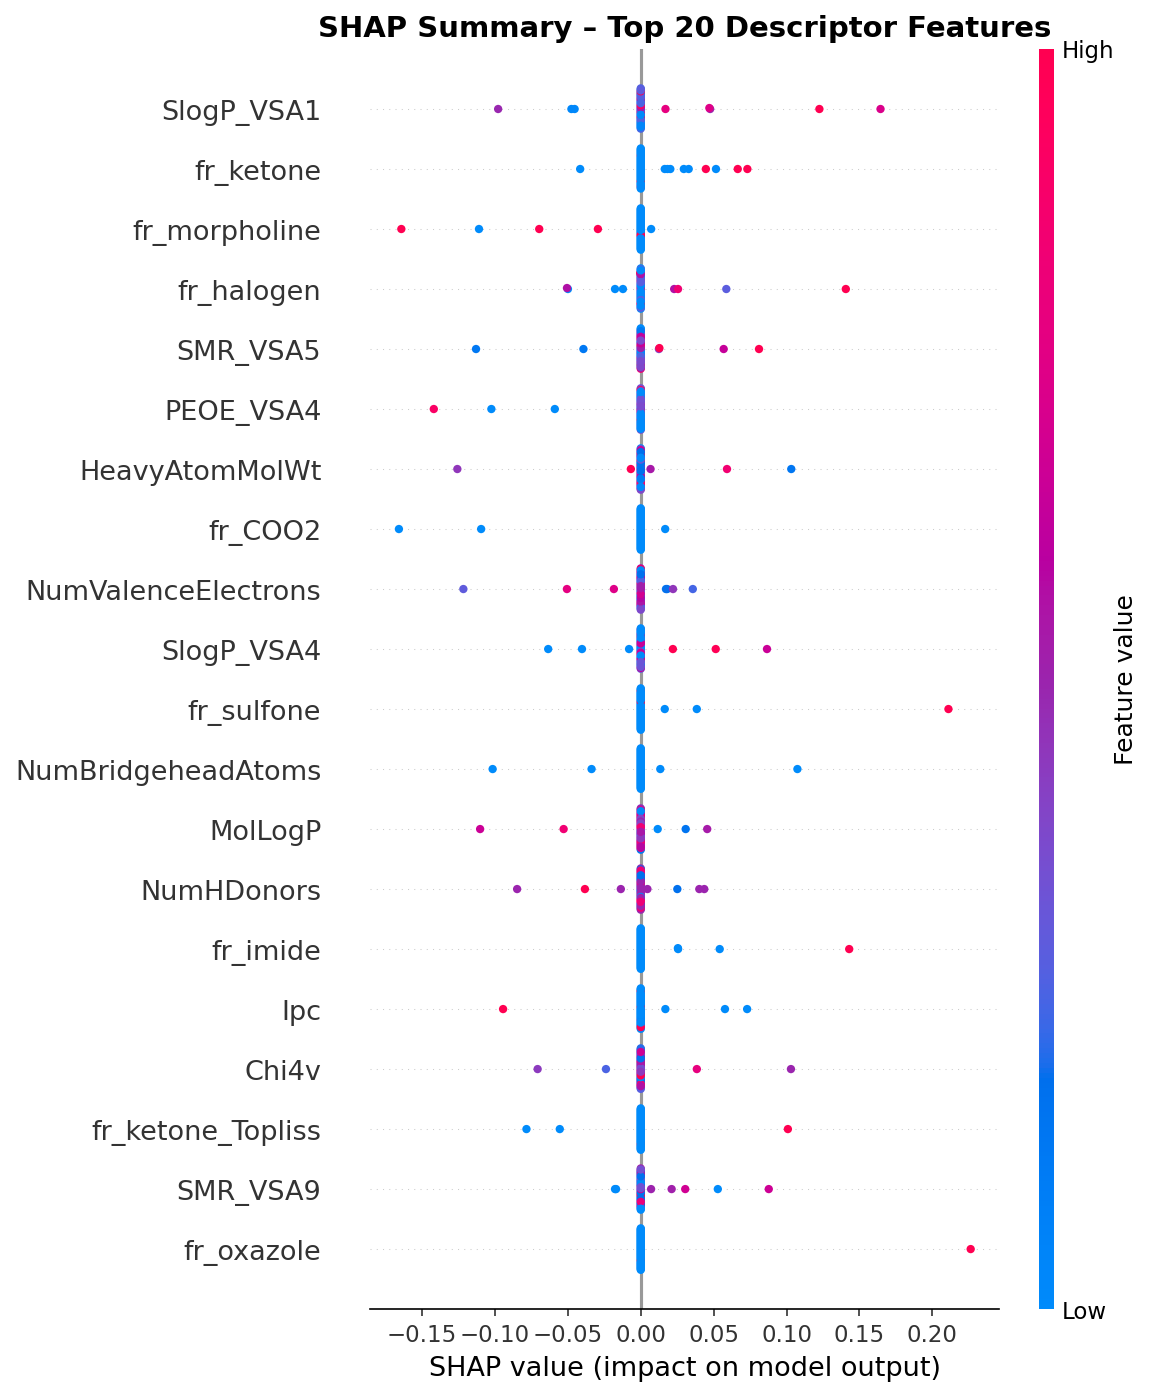

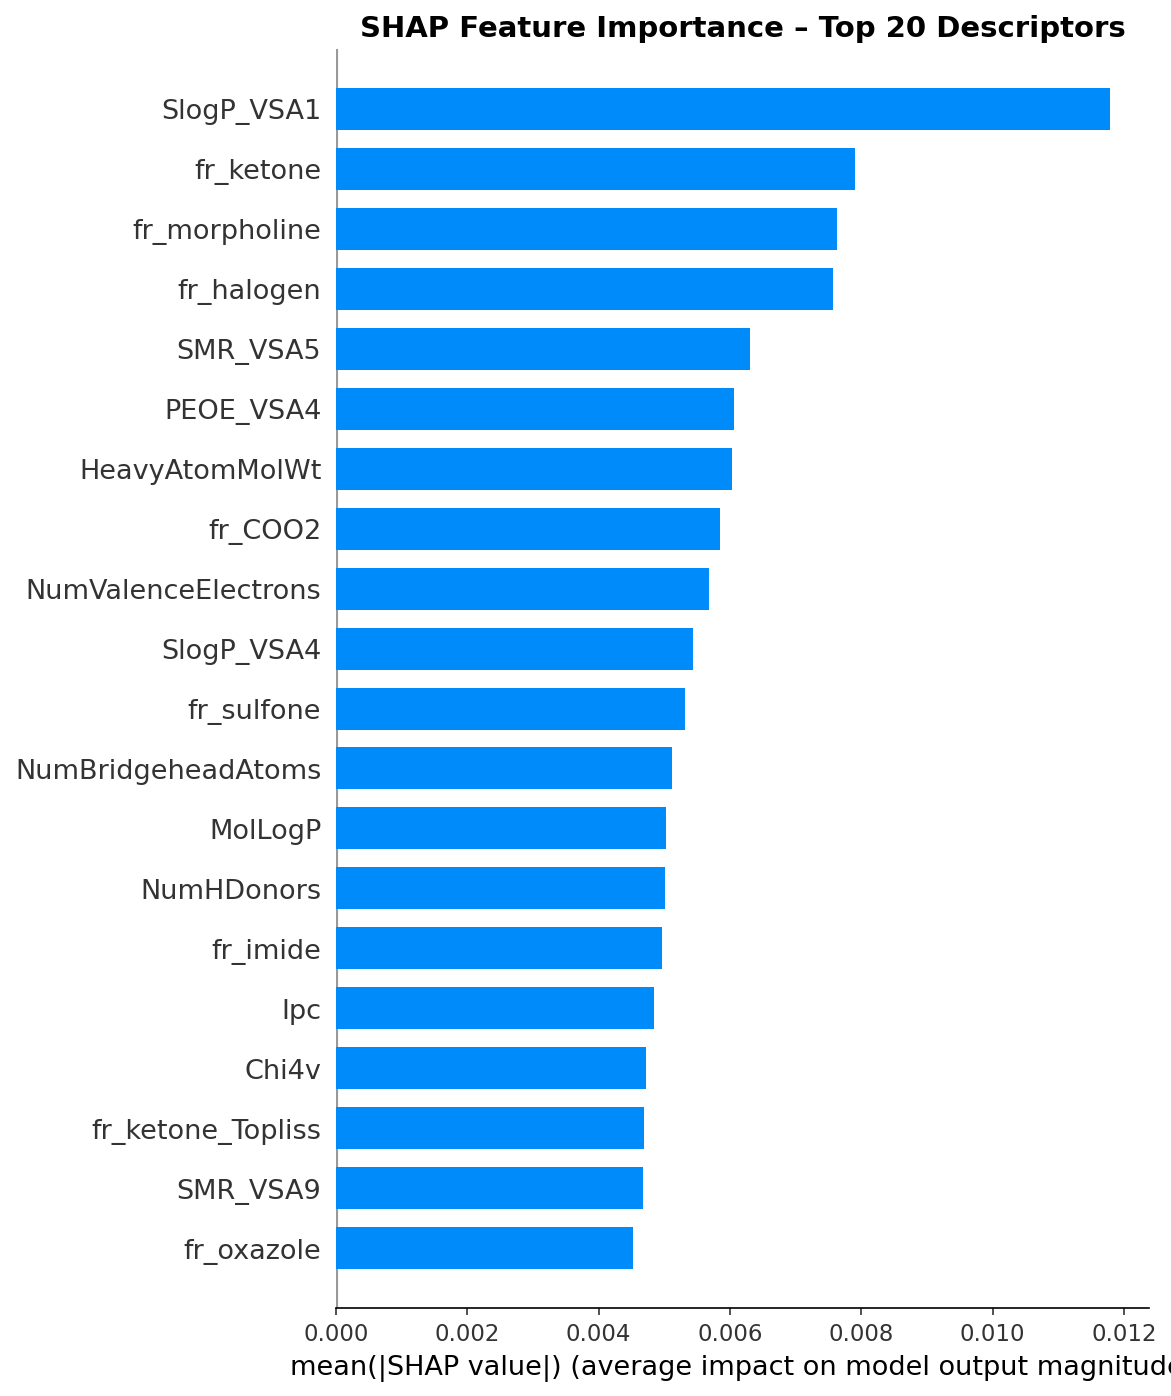


Top 20 Most Important Descriptor Features:
                 Feature  Mean_Abs_SHAP
71            SlogP_VSA1       0.011791
183            fr_ketone       0.007901
188        fr_morpholine       0.007629
176           fr_halogen       0.007576
66              SMR_VSA5       0.006313
55             PEOE_VSA4       0.006070
7         HeavyAtomMolWt       0.006036
141              fr_COO2       0.005844
9    NumValenceElectrons       0.005681
77            SlogP_VSA4       0.005439
209           fr_sulfone       0.005320
117   NumBridgeheadAtoms       0.005126
130              MolLogP       0.005024
119           NumHDonors       0.005005
180             fr_imide       0.004966
42                   Ipc       0.004842
40                 Chi4v       0.004723
184    fr_ketone_Topliss       0.004699
70              SMR_VSA9       0.004682
194           fr_oxazole       0.004527
Saved to: /content/drive/MyDrive/models_new/shap_descriptor_importance.csv


In [ ]:
# ================================================================
# 7b. SHAP ANALYSIS – DESCRIPTOR MODEL
# ================================================================
print("\n" + "="*80)
print("SHAP ANALYSIS – DESCRIPTOR MODEL")
print("="*80)

# Prepare background from trainval set (same preprocessing as first fold)
np.random.seed(42)
# Use a subset of trainval (already clipped & scaled with first fold's scaler)
Xd_bg_full = np.clip(X_desc_trainval[:1000], d_lo, d_hi)
Xd_bg_full = scaler_desc_shap.transform(Xd_bg_full).astype(np.float32)
background_size = min(100, len(Xd_bg_full))
background_indices = np.random.choice(len(Xd_bg_full), background_size, replace=False)
X_desc_background = Xd_bg_full[background_indices]

# Use the best descriptor model from the first fold
m_desc_shap = best_models['desc'][0]
print("\nCreating SHAP explainer for descriptor model...")
explainer_desc = shap.KernelExplainer(
    lambda x: m_desc_shap.predict(x, verbose=0).ravel(),
    X_desc_background
)

# Use the already scaled test descriptors (X_desc_test_shap)
test_sample_size = min(50, len(X_desc_test_shap))
test_indices = np.random.choice(len(X_desc_test_shap), test_sample_size, replace=False)
X_desc_test_sample = X_desc_test_shap[test_indices]

print(f"\nCalculating SHAP values for {test_sample_size} test samples...")
shap_values_desc = explainer_desc.shap_values(X_desc_test_sample, nsamples=100)

# Feature names (using original descriptor column names)
desc_feature_names = desc_feat_cols  # global from data loading

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_desc, X_desc_test_sample,
                  feature_names=desc_feature_names,
                  max_display=20, show=False)
plt.title('SHAP Summary – Top 20 Descriptor Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_descriptor_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

# SHAP bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_desc, X_desc_test_sample,
                  feature_names=desc_feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance – Top 20 Descriptors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_descriptor_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

#Feature importance
mean_abs_shap_desc = np.abs(shap_values_desc).mean(axis=0)
feature_importance_desc = pd.DataFrame({
    'Feature': desc_feature_names,
    'Mean_Abs_SHAP': mean_abs_shap_desc
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nTop 20 Most Important Descriptor Features:")
print(feature_importance_desc.head(20))
feature_importance_desc.to_csv(os.path.join(SAVE_DIR, 'shap_descriptor_importance.csv'), index=False)
print(f"Saved to: {os.path.join(SAVE_DIR, 'shap_descriptor_importance.csv')}")


SHAP ANALYSIS – FINGERPRINT MODEL
FP background shape (mean vector): (1, 2048)
Creating SHAP KernelExplainer for fingerprint model...
Computing SHAP values for 60 test samples (nsamples=200)...


  0%|          | 0/60 [00:00<?, ?it/s]

Active FP bits with non-zero SHAP: 445 / 2048


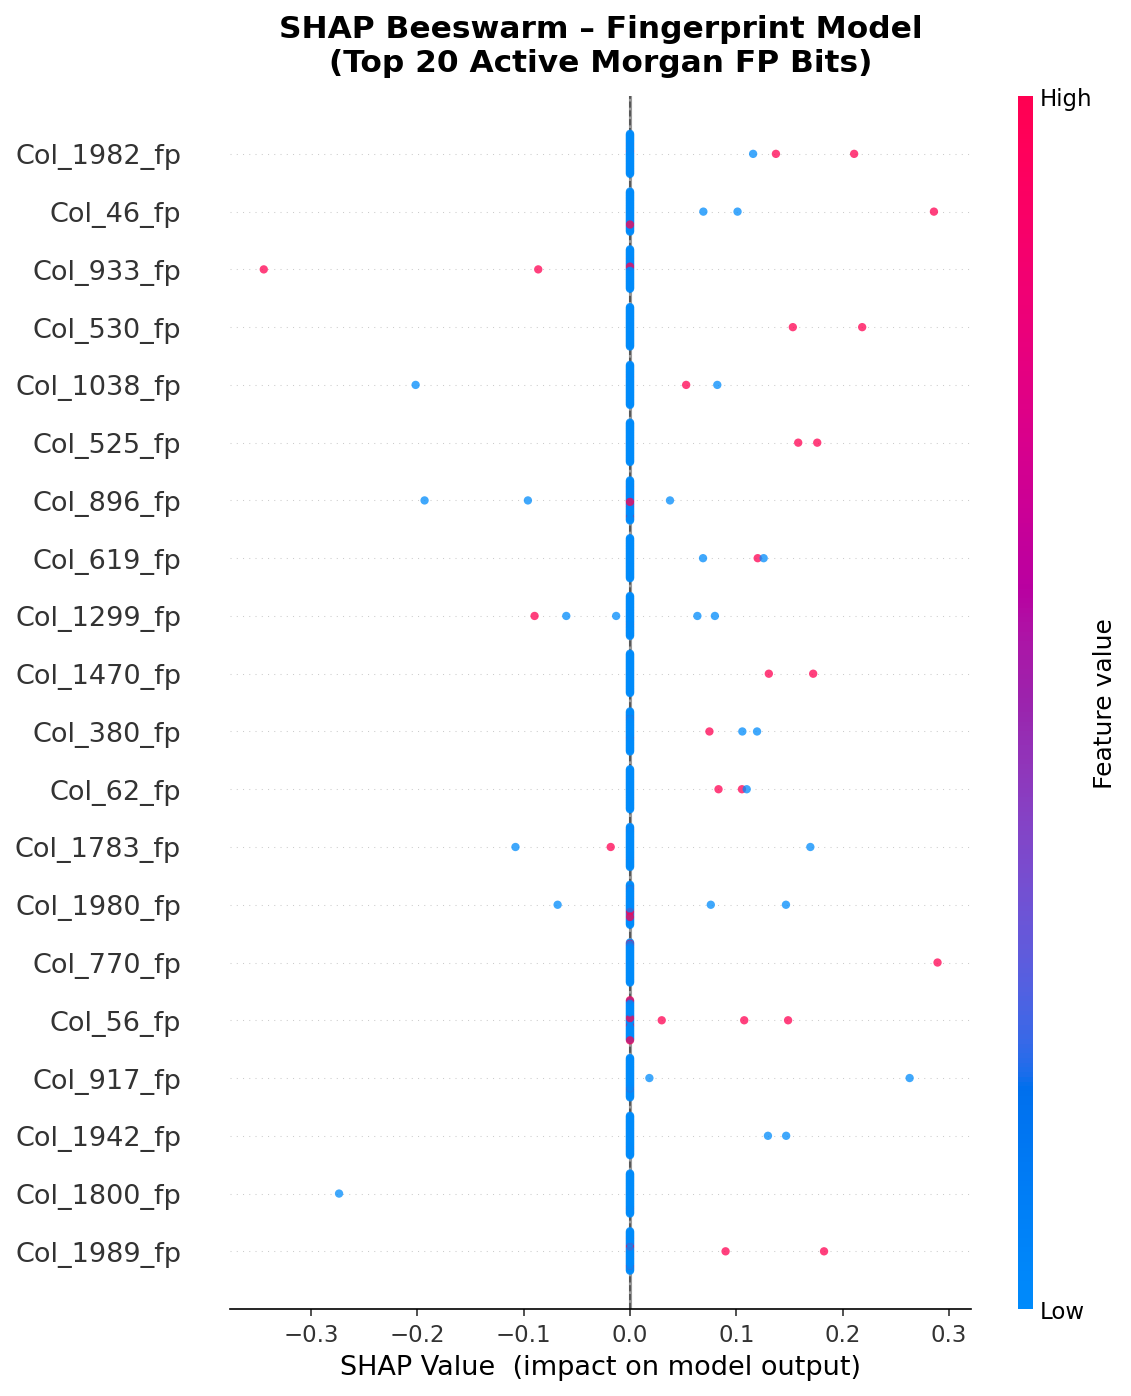

Saved: shap_fingerprint_summary.png


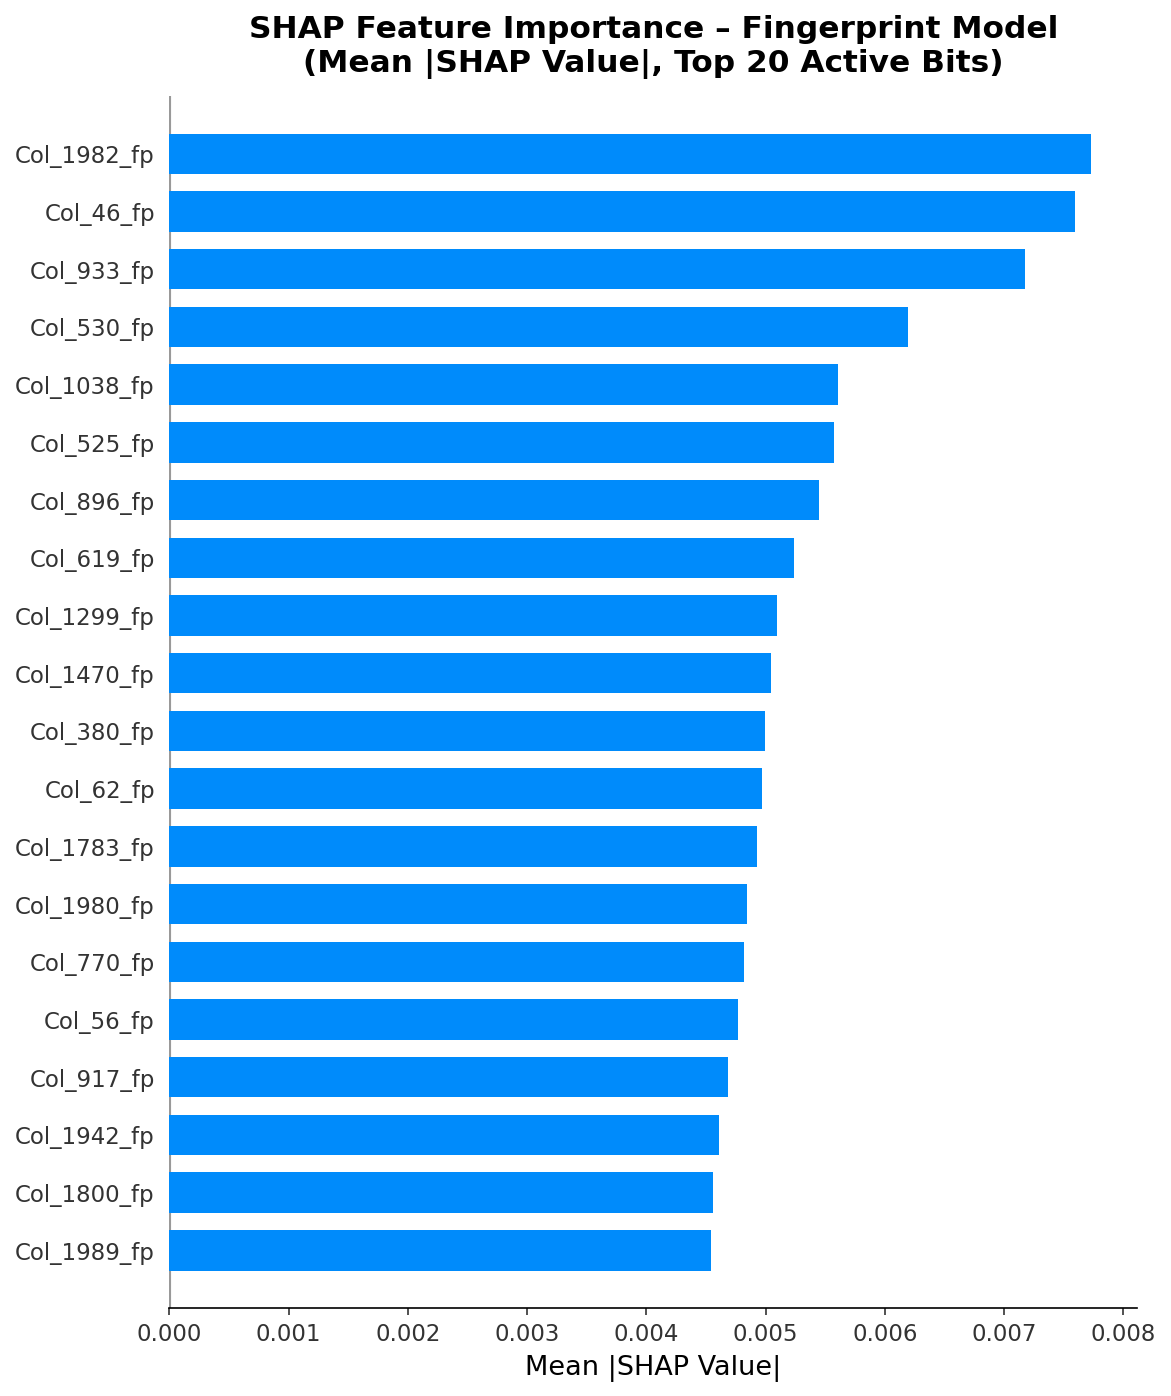

Saved: shap_fingerprint_bar.png


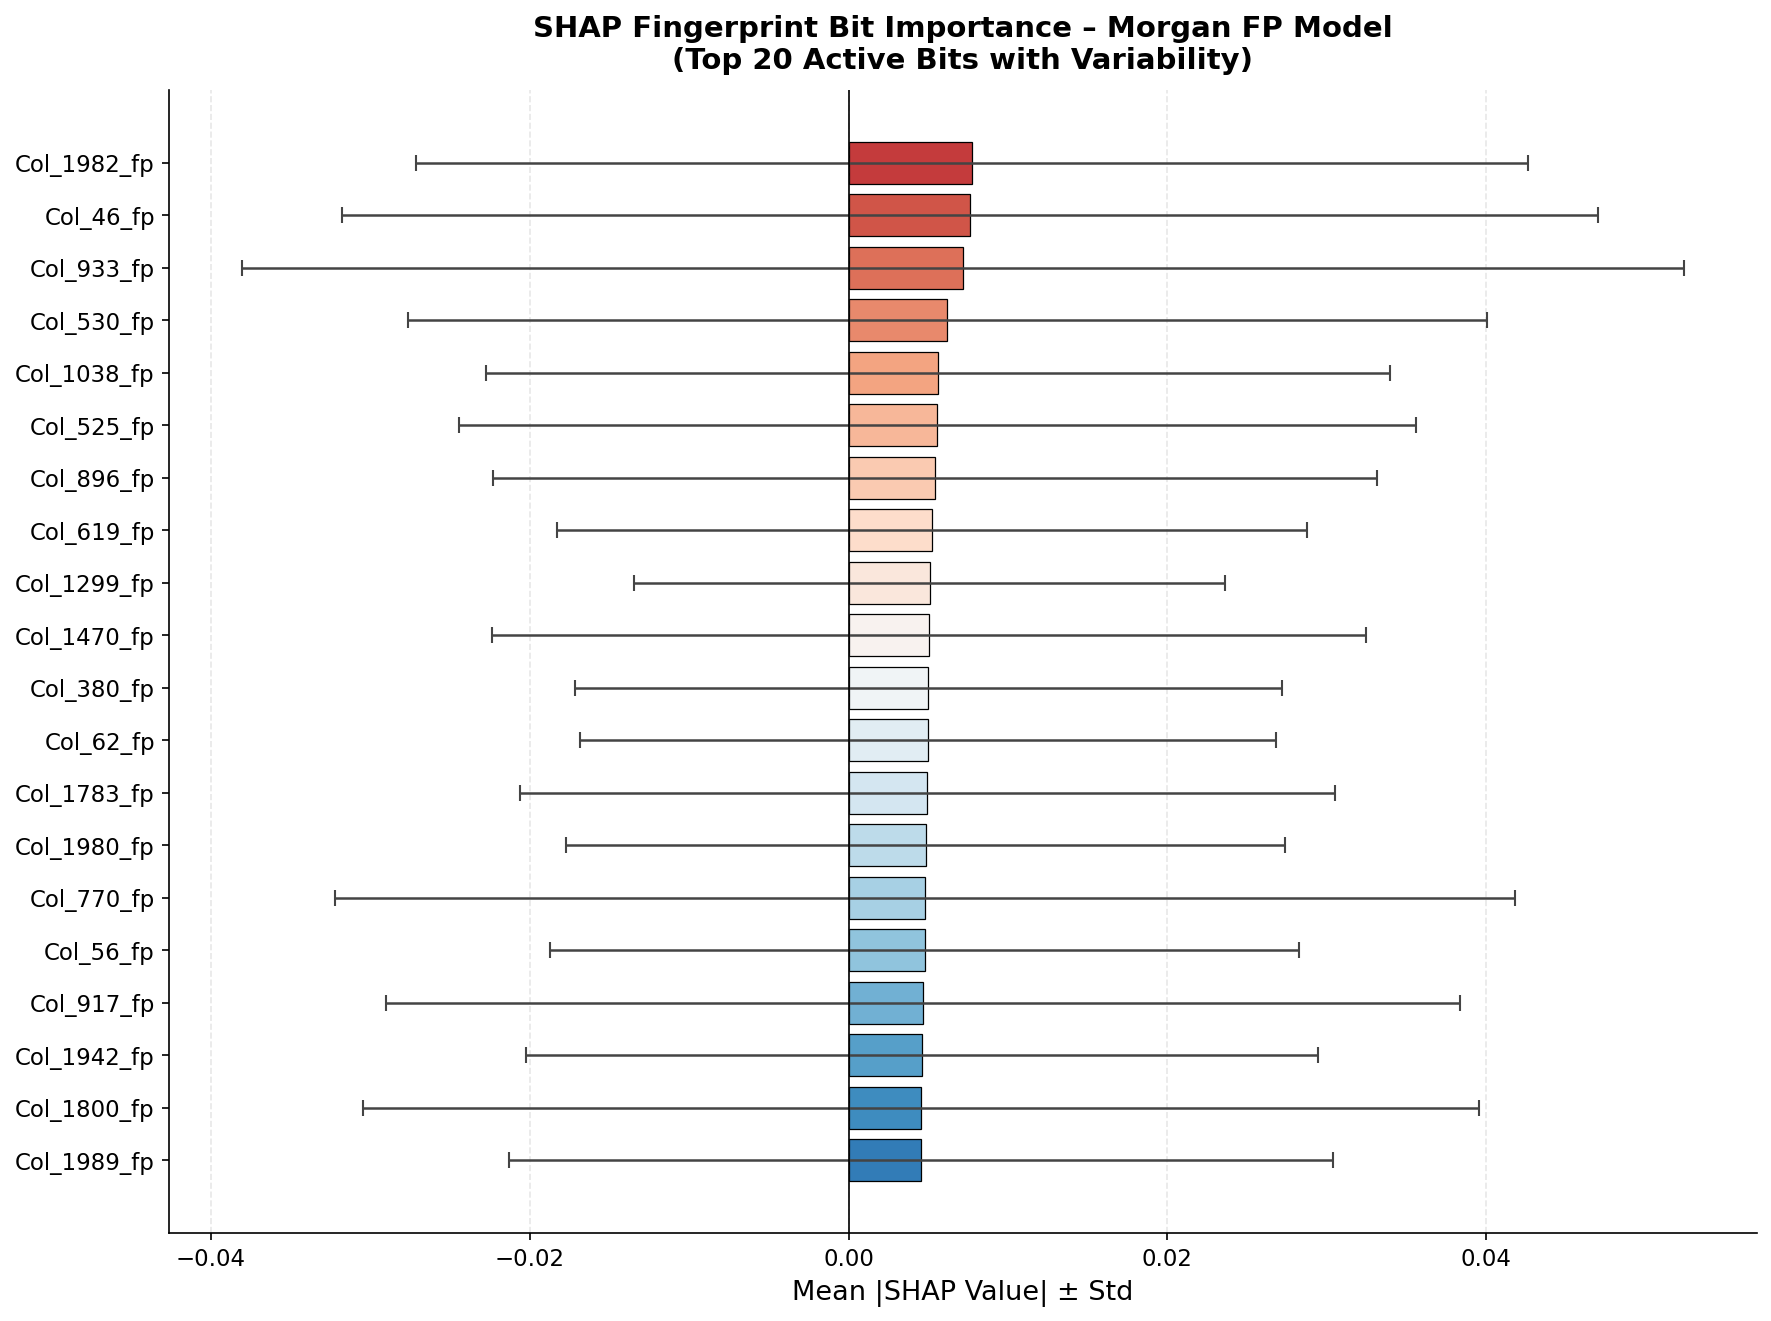

Saved: shap_fingerprint_ranked_bar.png


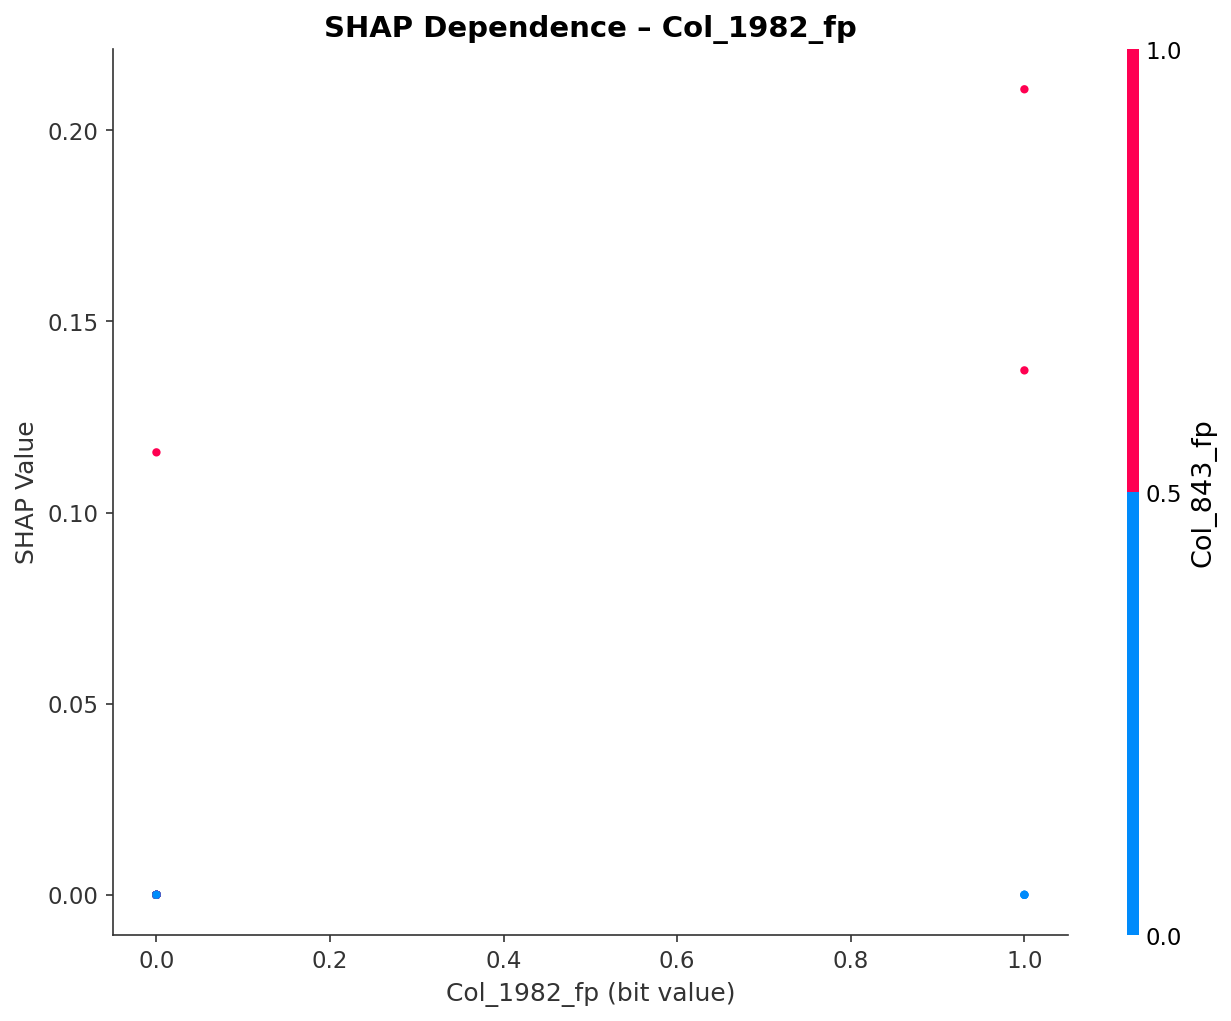

Saved: shap_fingerprint_dependence.png

Top 20 Most Important Fingerprint Bits:
    Feature  Mean_Abs_SHAP  Std_Abs_SHAP  Max_Abs_SHAP
Col_1982_fp       0.007728      0.034892      0.210736
  Col_46_fp       0.007597      0.039407      0.285758
 Col_933_fp       0.007176      0.045260      0.344318
 Col_530_fp       0.006190      0.033859      0.218290
Col_1038_fp       0.005607      0.028360      0.201545
 Col_525_fp       0.005570      0.030039      0.176039
 Col_896_fp       0.005445      0.027735      0.193145
 Col_619_fp       0.005240      0.023548      0.125666
Col_1299_fp       0.005097      0.018544      0.089719
Col_1470_fp       0.005046      0.027439      0.172232
 Col_380_fp       0.004996      0.022175      0.119453
  Col_62_fp       0.004970      0.021819      0.109728
Col_1783_fp       0.004923      0.025567      0.169563
Col_1980_fp       0.004844      0.022544      0.146630
 Col_770_fp       0.004819      0.037015      0.289135
  Col_56_fp       0.004764      0.023506

In [ ]:
# ================================================================
# 7c. SHAP ANALYSIS – FINGERPRINT MODEL
# ================================================================
print("\n" + "="*80)
print("SHAP ANALYSIS – FINGERPRINT MODEL")
print("="*80)

np.random.seed(42)

Xf_bg_pool = np.clip(X_fp_trainval[:1000], f_lo, f_hi)
Xf_bg_pool = scaler_fp_shap.transform(Xf_bg_pool).astype(np.float32)
X_fp_background = Xf_bg_pool.mean(axis=0, keepdims=True)   # shape (1, n_fp)
print(f"FP background shape (mean vector): {X_fp_background.shape}")

m_fp_shap = best_models['fp'][0]
print("Creating SHAP KernelExplainer for fingerprint model...")
explainer_fp = shap.KernelExplainer(
    lambda x: m_fp_shap.predict(x, verbose=0).ravel(),
    X_fp_background
)

test_sample_size_fp = min(60, len(X_fp_test_shap))
test_indices_fp     = np.random.choice(len(X_fp_test_shap), test_sample_size_fp, replace=False)
X_fp_test_sample    = X_fp_test_shap[test_indices_fp]

print(f"Computing SHAP values for {test_sample_size_fp} test samples (nsamples=200)...")
shap_values_fp = explainer_fp.shap_values(X_fp_test_sample, nsamples=200)

shap_max_fp  = np.abs(shap_values_fp).max(axis=0)
active_fp    = np.where(shap_max_fp > 1e-8)[0]
print(f"Active FP bits with non-zero SHAP: {len(active_fp)} / {shap_values_fp.shape[1]}")

shap_fp_active  = shap_values_fp[:, active_fp]
X_fp_active     = X_fp_test_sample[:, active_fp]
fp_feat_names   = fp_feat_cols
names_fp_active = [fp_feat_names[i] for i in active_fp]

#Beeswarm / Summary plot
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_fp_active, X_fp_active,
                  feature_names=names_fp_active,
                  max_display=20, show=False, alpha=0.75)
ax = plt.gca()
ax.set_title("SHAP Beeswarm – Fingerprint Model\n(Top 20 Active Morgan FP Bits)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("SHAP Value  (impact on model output)", fontsize=13)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_summary.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_summary.png")

#Bar plot
mean_abs_shap_fp = np.abs(shap_fp_active).mean(axis=0)
top20_local      = np.argsort(mean_abs_shap_fp)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_fp_active, X_fp_active,
                  feature_names=names_fp_active,
                  plot_type='bar', max_display=20, show=False)
ax = plt.gca()
ax.set_title("SHAP Feature Importance – Fingerprint Model\n(Mean |SHAP Value|, Top 20 Active Bits)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("Mean |SHAP Value|", fontsize=13)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_bar.png")

#Custom ranked bar chart with error bars (std)
top_k           = min(20, len(active_fp))
top_k_local_idx = np.argsort(mean_abs_shap_fp)[::-1][:top_k]
top_names       = [names_fp_active[i] for i in top_k_local_idx]
top_means       = mean_abs_shap_fp[top_k_local_idx]
top_stds        = np.abs(shap_fp_active[:, top_k_local_idx]).std(axis=0)

fig, ax = plt.subplots(figsize=(12, 9))
colors_bar = plt.cm.RdBu_r(np.linspace(0.15, 0.85, top_k))[::-1]
bars = ax.barh(range(top_k)[::-1], top_means, xerr=top_stds,
               color=colors_bar, edgecolor='black', linewidth=0.6,
               error_kw=dict(ecolor='#444444', capsize=4, elinewidth=1.2))
ax.set_yticks(range(top_k)[::-1])
ax.set_yticklabels(top_names, fontsize=11)
ax.set_xlabel("Mean |SHAP Value| ± Std", fontsize=13)
ax.set_title("SHAP Fingerprint Bit Importance – Morgan FP Model\n(Top 20 Active Bits with Variability)",
             fontsize=14, fontweight='bold', pad=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_ranked_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_ranked_bar.png")

#Dependence plot (top FP bit)
top1_local = int(top_k_local_idx[0])
fig, ax    = plt.subplots(figsize=(9, 7))
shap.dependence_plot(top1_local, shap_fp_active, X_fp_active,
                     feature_names=names_fp_active, show=False, ax=ax)
ax.set_title(f"SHAP Dependence – {names_fp_active[top1_local]}",
             fontsize=14, fontweight='bold')
ax.set_xlabel(f"{names_fp_active[top1_local]} (bit value)", fontsize=12)
ax.set_ylabel("SHAP Value", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_dependence.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_dependence.png")

#Importance table
feature_importance_fp = pd.DataFrame({
    'Feature':       names_fp_active,
    'Mean_Abs_SHAP': mean_abs_shap_fp,
    'Std_Abs_SHAP':  np.abs(shap_fp_active).std(axis=0),
    'Max_Abs_SHAP':  shap_max_fp[active_fp],
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nTop 20 Most Important Fingerprint Bits:")
print(feature_importance_fp.head(20).to_string(index=False))
feature_importance_fp.to_csv(os.path.join(SAVE_DIR, 'shap_fingerprint_importance.csv'), index=False)
print(f"\nSaved: shap_fingerprint_importance.csv")


In [ ]:
# ================================================================
# 8. HELPER FUNCTIONS FOR MOLECULAR VISUALIZATION
# ================================================================
def get_morgan_fingerprint_info(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=bit_info)
    return fp, bit_info

def highlight_atoms_and_bonds(smiles, important_bits, bit_info, top_n=5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)

    atom_highlights = set()
    bond_highlights = set()

    for bit_idx in important_bits[:top_n]:
        if bit_idx in bit_info:
            for center_atom, radius in bit_info[bit_idx]:
                atom_highlights.add(center_atom)
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom)
                for bond_idx in env:
                    bond = mol.GetBondWithIdx(bond_idx)
                    atom_highlights.add(bond.GetBeginAtomIdx())
                    atom_highlights.add(bond.GetEndAtomIdx())
                    bond_highlights.add(bond_idx)

    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
    except AttributeError:
        drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)

    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atom_highlights),
        highlightBonds=list(bond_highlights),
        highlightAtomColors={a: (1.0, 0.7, 0.0) for a in atom_highlights},
        highlightBondColors={b: (1.0, 0.5, 0.0) for b in bond_highlights}
    )
    drawer.FinishDrawing()
    img_data = drawer.GetDrawingText()
    try:
        img = Image.open(BytesIO(img_data))
    except Exception:
        from IPython.display import SVG, display
        display(SVG(img_data))
        img = None
    return img


PREDICTIONS AND EXPLAINABILITY FOR TEST MOLECULES
  Preparing SHAP for Imatinib...


  0%|          | 0/1 [00:00<?, ?it/s]

[07:31:49] DEPRECATION WARNING: please use MorganGenerator


  Preparing SHAP for Neratinib...


  0%|          | 0/1 [00:00<?, ?it/s]

...

[07:32:01] DEPRECATION WARNING: please use MorganGenerator


✗ Dasatinib not found in dataset
✗ Navitoclax not found in dataset
  Preparing SHAP for Silmitasertib...


  0%|          | 0/1 [00:00<?, ?it/s]

[07:32:04] DEPRECATION WARNING: please use MorganGenerator



SUMMARY OF PREDICTIONS FOR ALL TEST MOLECULES
      Molecule  Combined_Prob  Combined_Pred  Desc_Prob  FP_Prob
      Imatinib       0.426057              0   0.412968 0.414278
     Neratinib       0.031055              0   0.028315 0.027572
   Sitagliptin       0.952348              1   0.970335 0.979514
     Sunitinib       0.439263              0   0.448717 0.446161
Leucettinib-92       0.582512              1   0.506526 0.527172
 Silmitasertib       0.523488              1   0.550487 0.542538

✓ Predictions saved to: /content/drive/MyDrive/models_new/test_molecules_predictions.csv

GENERATING SHAP VISUALISATIONS FOR ALL TEST MOLECULES

--- Imatinib ---
  Top 10 fingerprint features:
    1. Feature 240 (Bit 240): SHAP = -0.139553
    2. Feature 1736 (Bit 1736): SHAP = 0.113678
    3. Feature 1035 (Bit 1035): SHAP = -0.112849
    4. Feature 1950 (Bit 1950): SHAP = 0.085337
    5. Feature 802 (Bit 802): SHAP = 0.076680
    6. Feature 1597 (Bit 1597): SHAP = 0.074211
    7. Feature 197

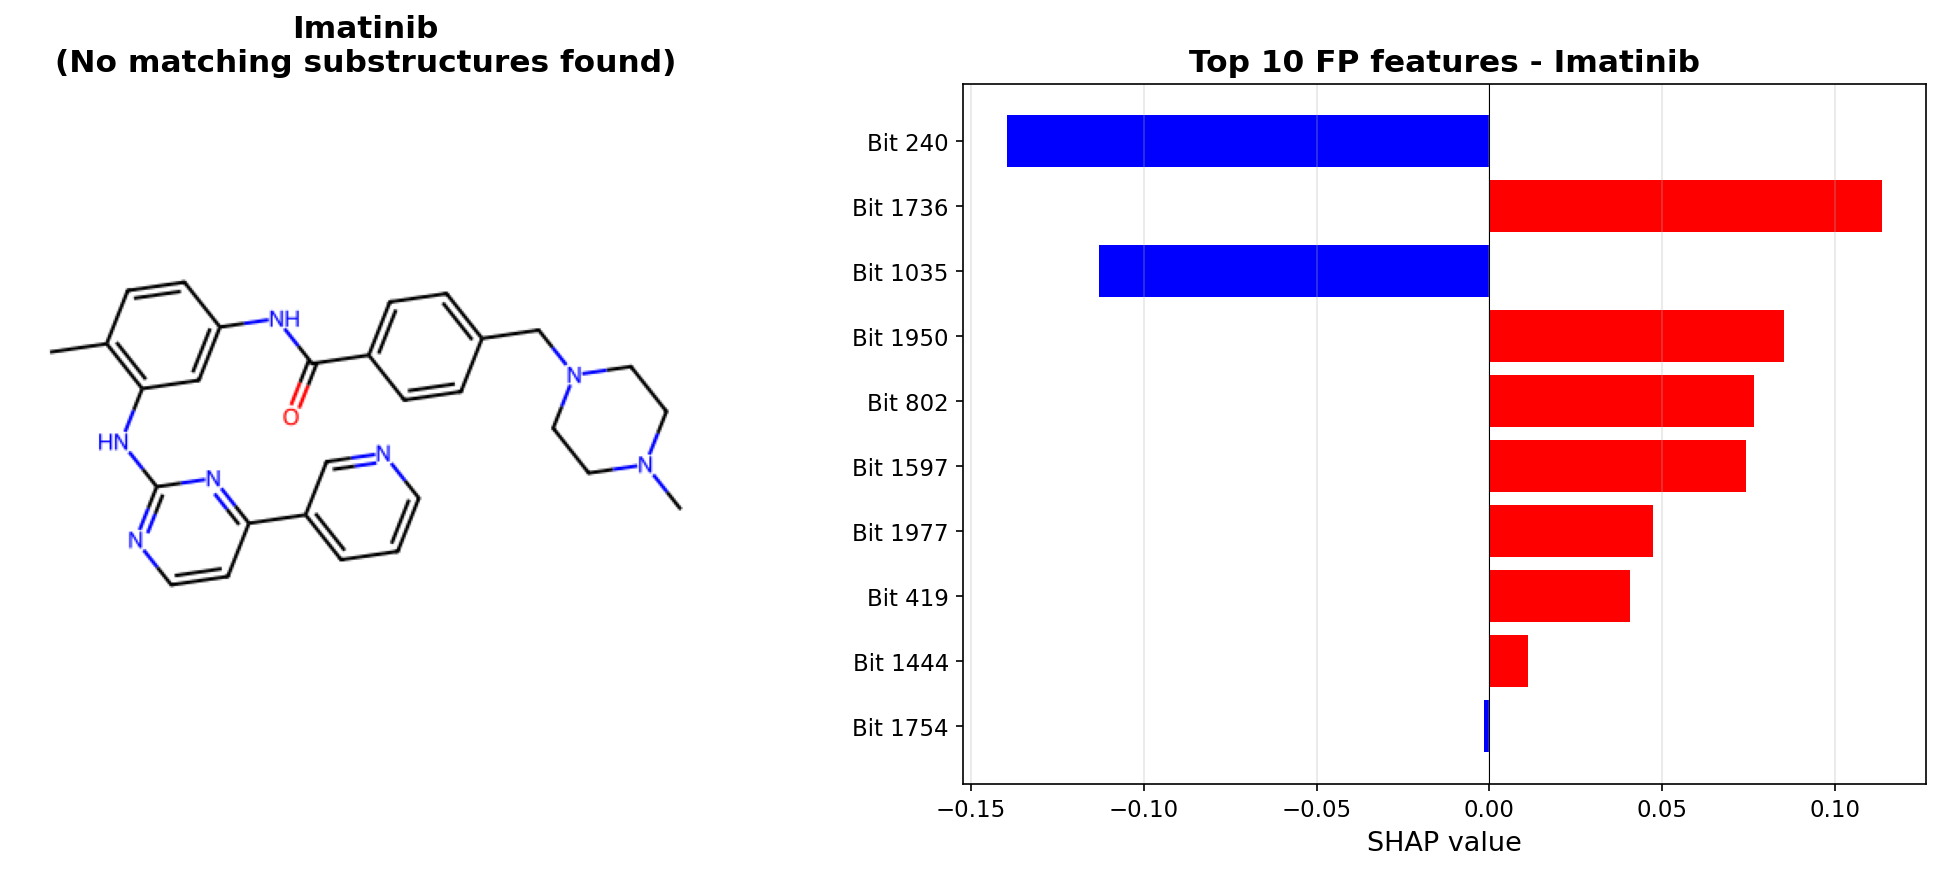


--- Neratinib ---
  Top 10 fingerprint features:
    1. Feature 5 (Bit 5): SHAP = 0.283355
    2. Feature 1817 (Bit 1817): SHAP = -0.202858
    3. Feature 674 (Bit 674): SHAP = -0.188804
    4. Feature 524 (Bit 524): SHAP = 0.151662
    5. Feature 222 (Bit 222): SHAP = -0.135595
    6. Feature 448 (Bit 448): SHAP = -0.124389
    7. Feature 352 (Bit 352): SHAP = 0.064013
    8. Feature 726 (Bit 726): SHAP = -0.029677
    9. Feature 2032 (Bit 2032): SHAP = -0.025635
    10. Feature 1508 (Bit 1508): SHAP = -0.002370


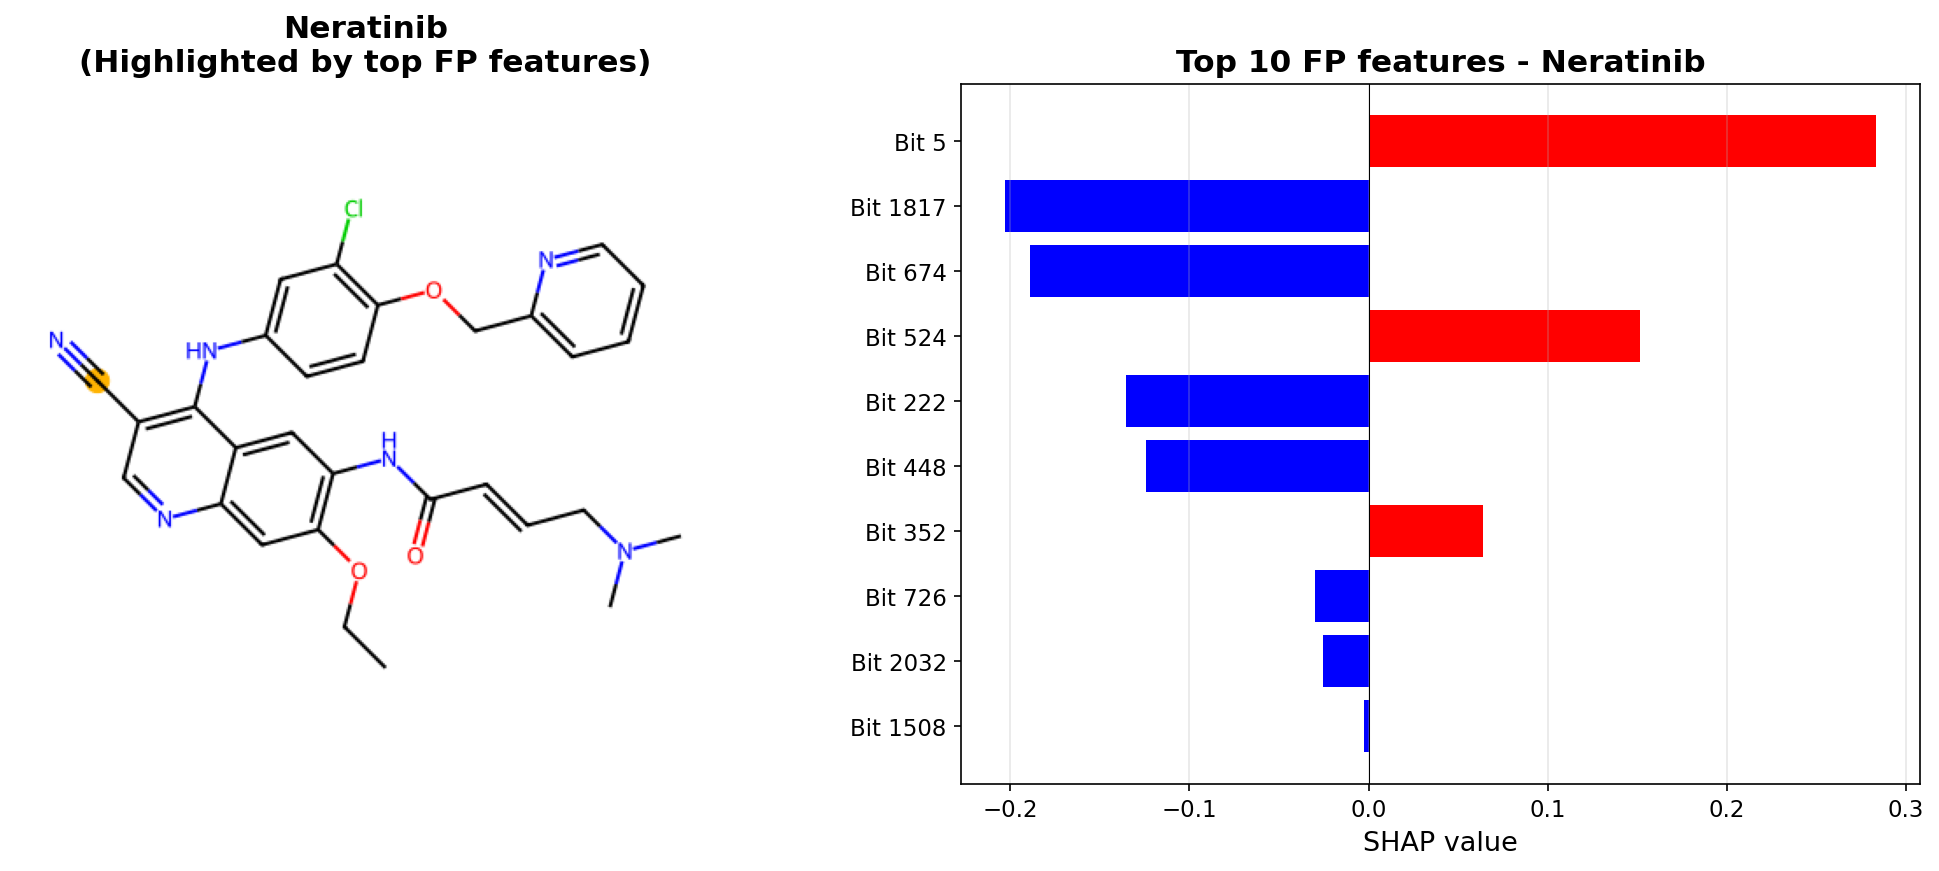


--- Sitagliptin ---
  Top 10 fingerprint features:
    1. Feature 1934 (Bit 1934): SHAP = 0.514365
    2. Feature 1993 (Bit 1993): SHAP = 0.364850
    3. Feature 1860 (Bit 1860): SHAP = -0.121529
    4. Feature 557 (Bit 557): SHAP = -0.121529
    5. Feature 267 (Bit 267): SHAP = 0.091724
    6. Feature 1164 (Bit 1164): SHAP = 0.067469
    7. Feature 325 (Bit 325): SHAP = -0.031218
    8. Feature 1308 (Bit 1308): SHAP = 0.008843
    9. Feature 686 (Bit 686): SHAP = 0.000000
    10. Feature 684 (Bit 684): SHAP = 0.000000


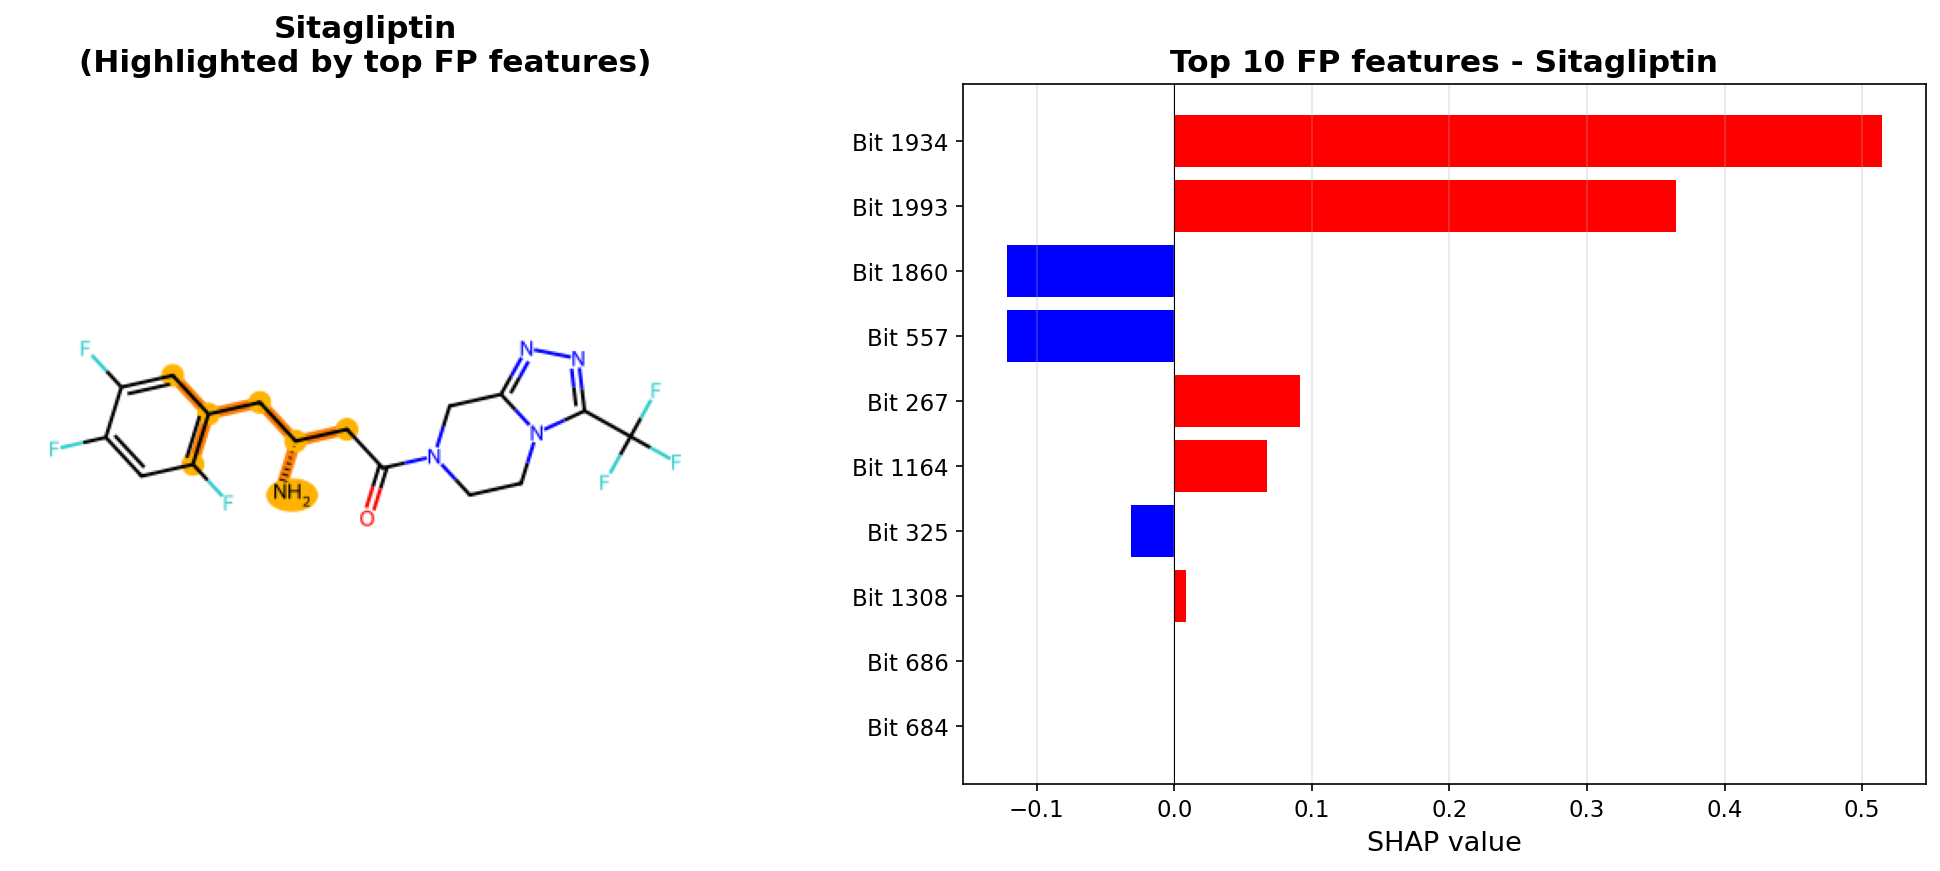


--- Sunitinib ---
  Top 10 fingerprint features:
    1. Feature 1922 (Bit 1922): SHAP = -0.287116
    2. Feature 1992 (Bit 1992): SHAP = 0.243702
    3. Feature 1660 (Bit 1660): SHAP = 0.122427
    4. Feature 1612 (Bit 1612): SHAP = 0.094010
    5. Feature 357 (Bit 357): SHAP = 0.064444
    6. Feature 1382 (Bit 1382): SHAP = -0.022187
    7. Feature 1991 (Bit 1991): SHAP = -0.018901
    8. Feature 301 (Bit 301): SHAP = 0.015467
    9. Feature 1000 (Bit 1000): SHAP = 0.014124
    10. Feature 544 (Bit 544): SHAP = 0.003109


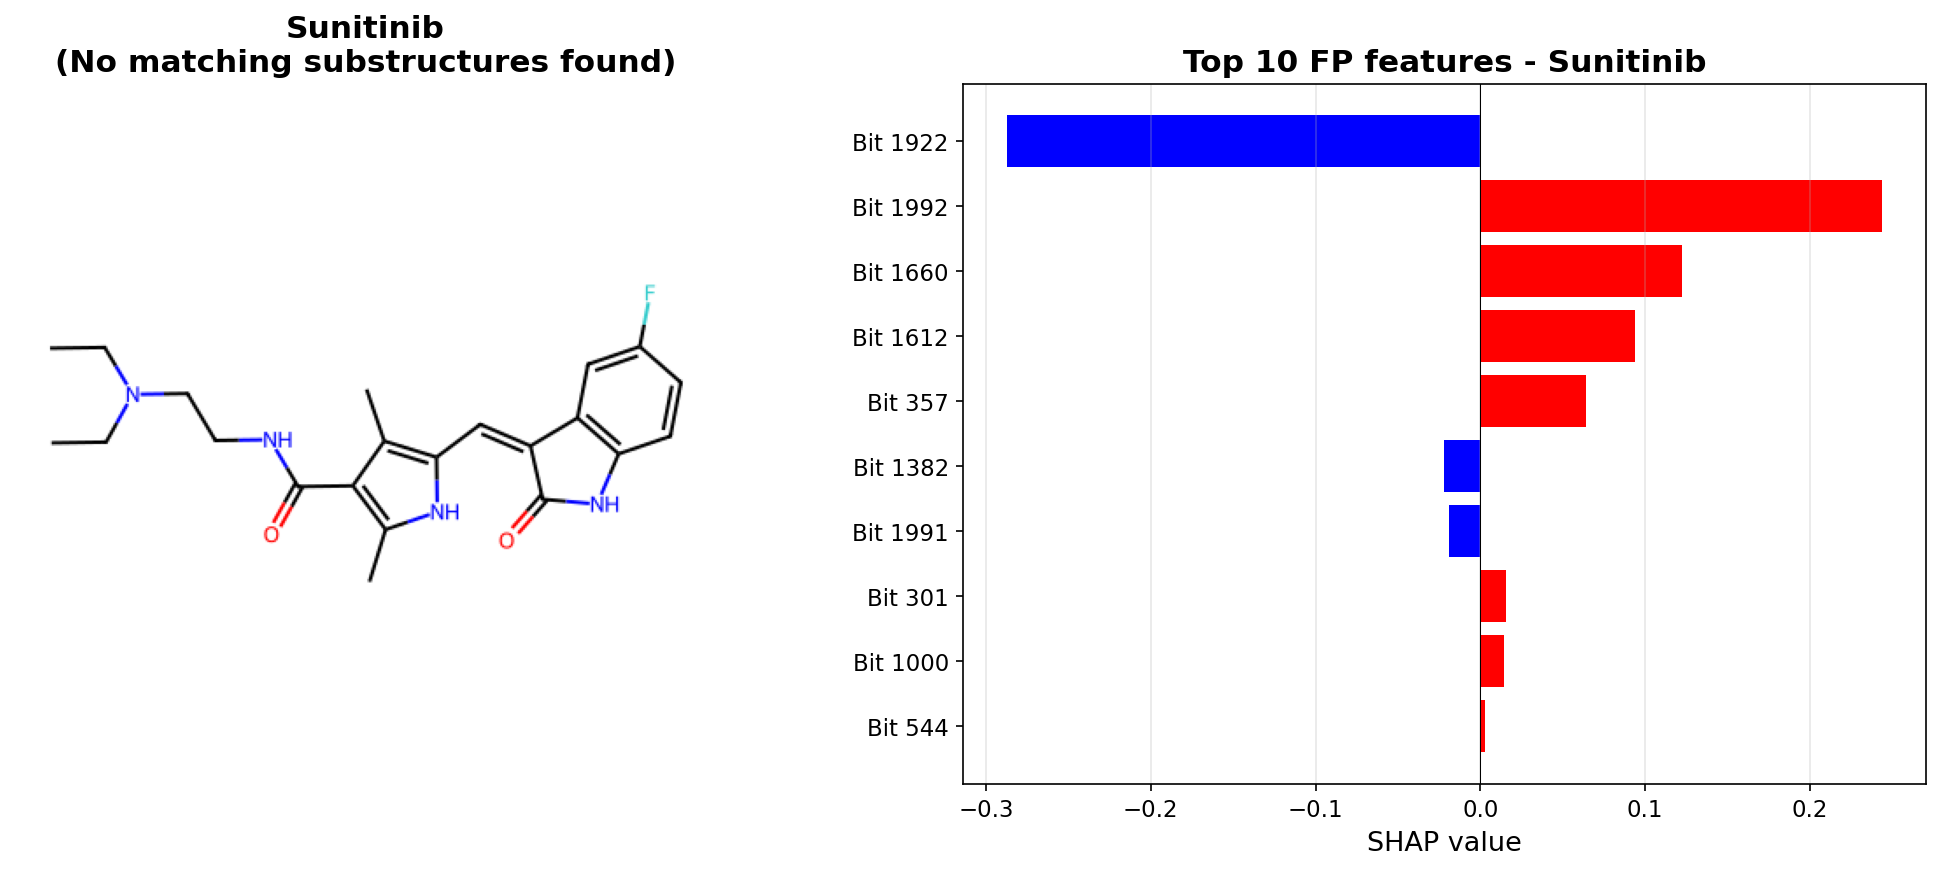


--- Leucettinib-92 ---
  Top 10 fingerprint features:
    1. Feature 80 (Bit 80): SHAP = 0.174592
    2. Feature 1724 (Bit 1724): SHAP = -0.171608
    3. Feature 1833 (Bit 1833): SHAP = 0.132979
    4. Feature 270 (Bit 270): SHAP = -0.116447
    5. Feature 1362 (Bit 1362): SHAP = 0.069475
    6. Feature 1032 (Bit 1032): SHAP = 0.060559
    7. Feature 1101 (Bit 1101): SHAP = 0.058454
    8. Feature 1447 (Bit 1447): SHAP = 0.028485
    9. Feature 283 (Bit 283): SHAP = 0.017423
    10. Feature 1190 (Bit 1190): SHAP = 0.016629


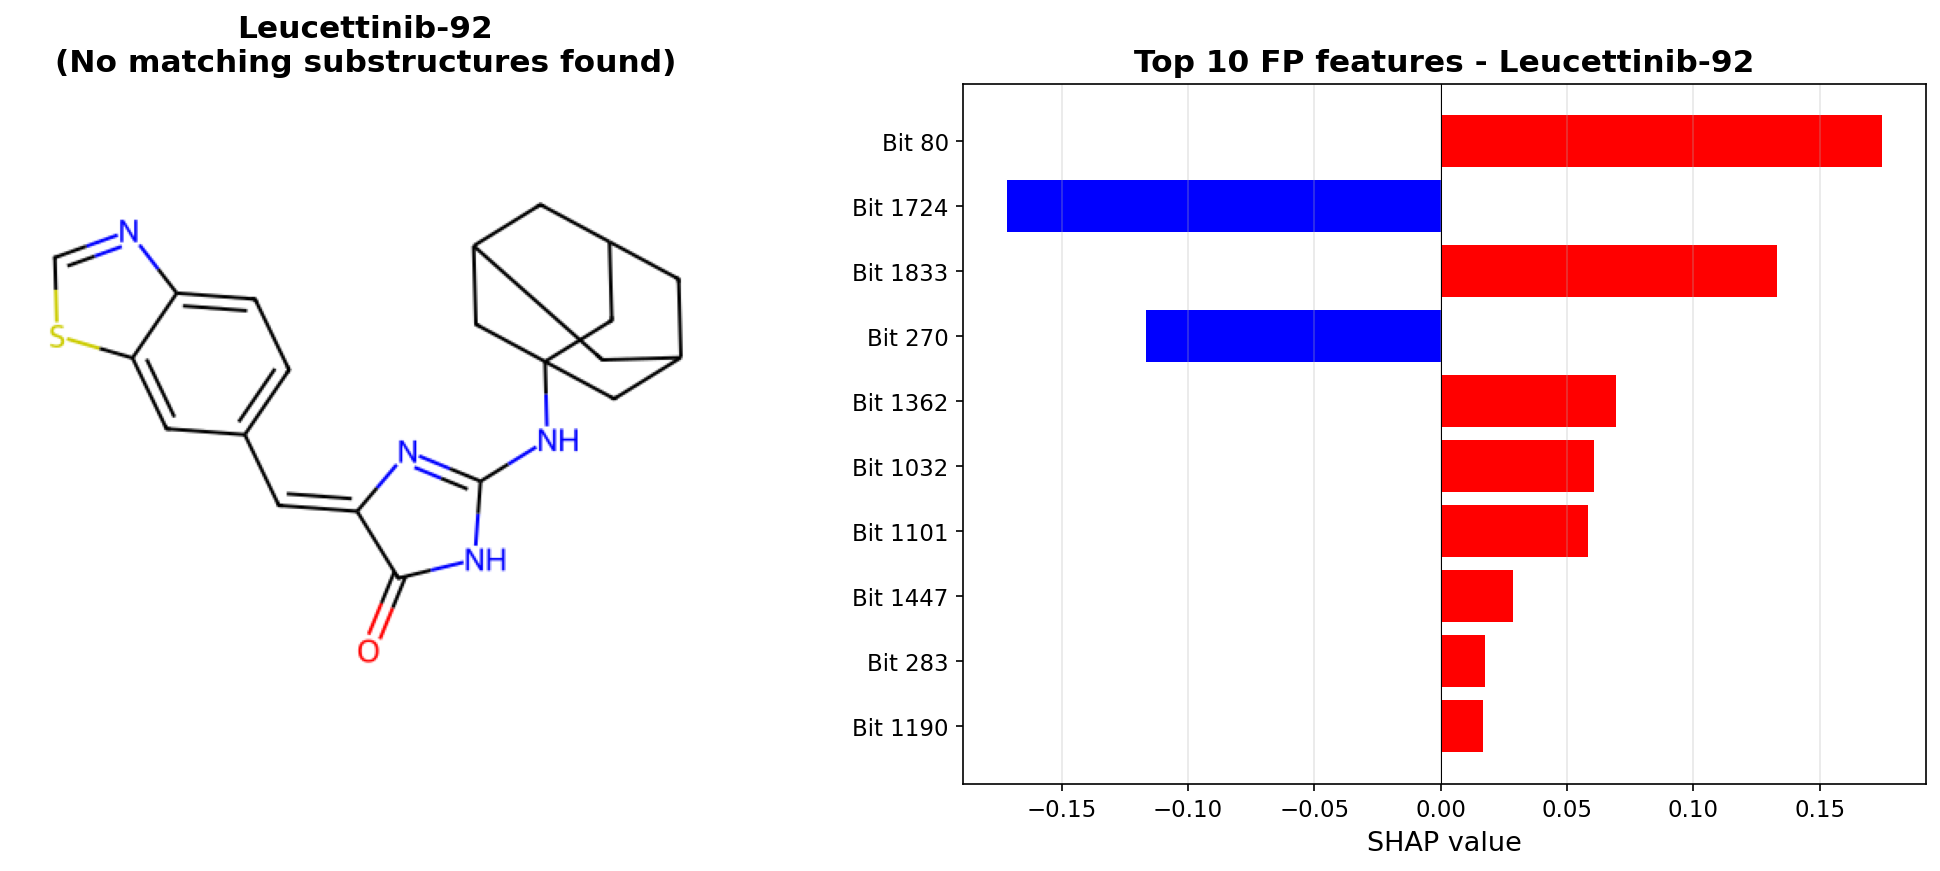


--- Silmitasertib ---
  Top 10 fingerprint features:
    1. Feature 1744 (Bit 1744): SHAP = 0.107518
    2. Feature 1574 (Bit 1574): SHAP = 0.102314
    3. Feature 546 (Bit 546): SHAP = 0.084446
    4. Feature 99 (Bit 99): SHAP = 0.058048
    5. Feature 204 (Bit 204): SHAP = 0.053319
    6. Feature 771 (Bit 771): SHAP = 0.036950
    7. Feature 1943 (Bit 1943): SHAP = 0.032676
    8. Feature 203 (Bit 203): SHAP = 0.028687
    9. Feature 1146 (Bit 1146): SHAP = 0.007764
    10. Feature 1570 (Bit 1570): SHAP = 0.002212


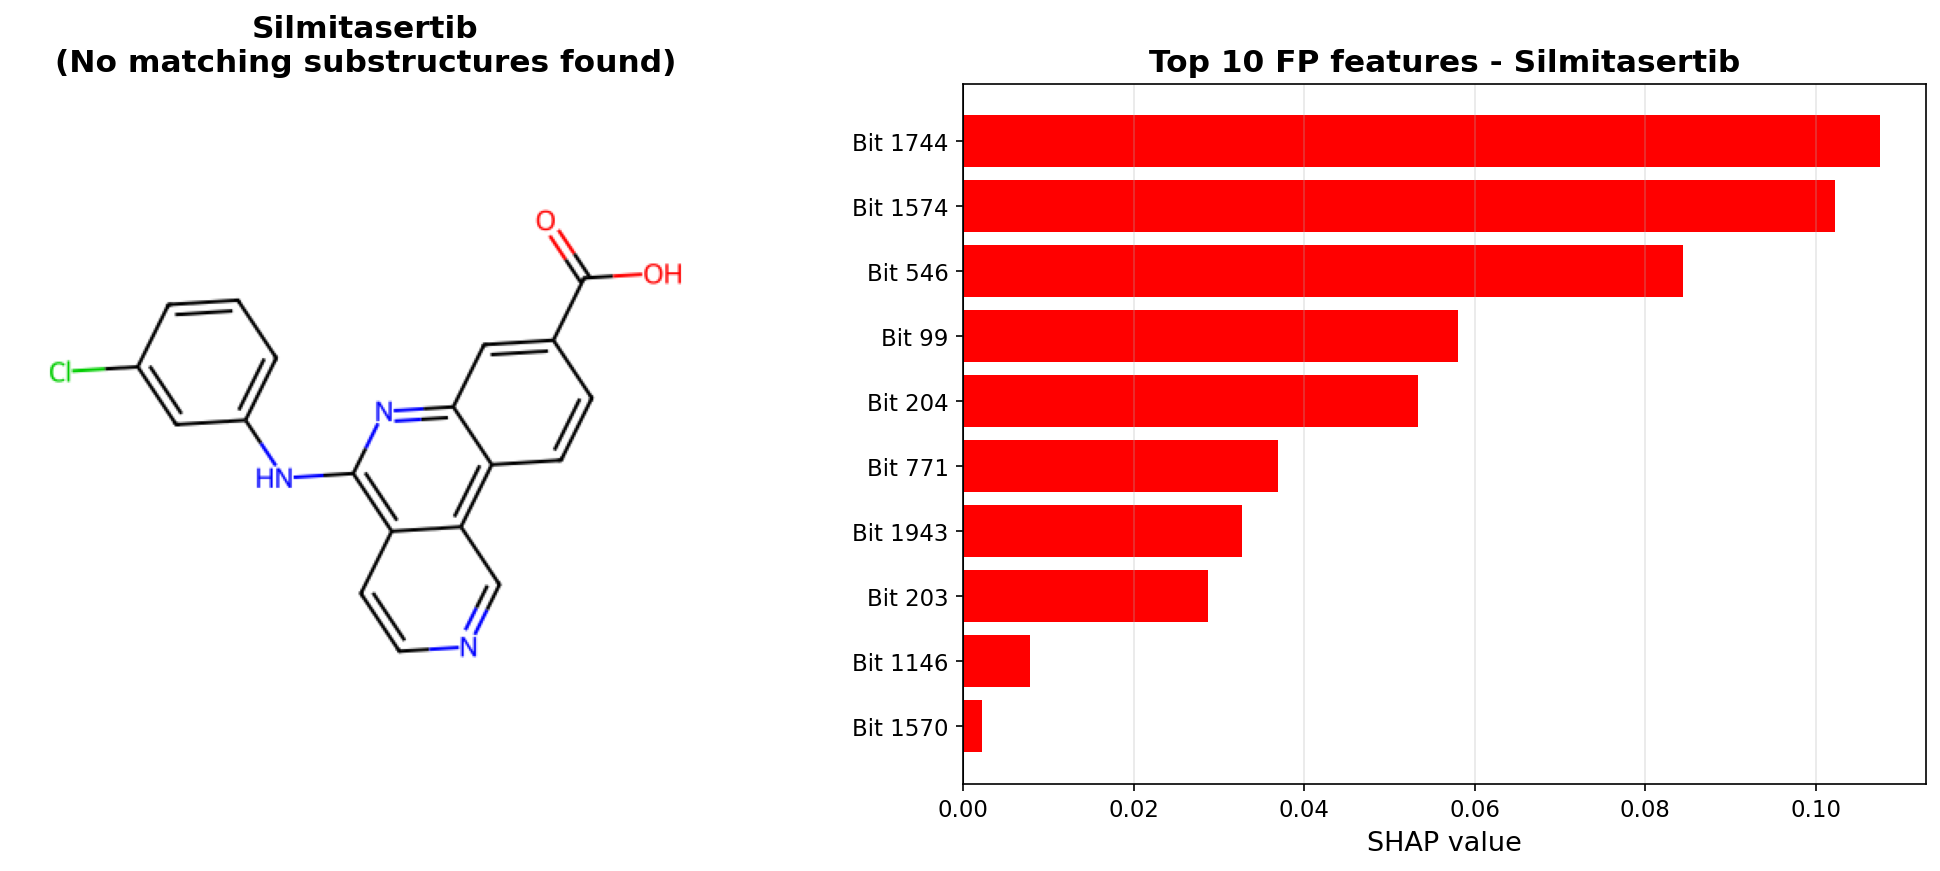


PIPELINE COMPLETED SUCCESSFULLY


In [ ]:
# ================================================================
# 9. PREDICTIONS ON TEST MOLECULES & FINGERPRINT SHAP HIGHLIGHTING
# ================================================================
print("\n" + "="*80)
print("PREDICTIONS AND EXPLAINABILITY FOR TEST MOLECULES")
print("="*80)

TEST_MOLECULES = {
    'Compound_name': [
        'Imatinib', 'Neratinib', 'Sitagliptin', 'Sunitinib',
        'Leucettinib-92', 'Dasatinib', 'Navitoclax', 'Silmitasertib'
    ],
    'ChEMBL_ID': [
        'CHEMBL941', 'CHEMBL180022', 'CHEMBL1422', 'CHEMBL535',
        'CHEMBL5091238', 'CHEMBL1421', 'CHEMBL443684', 'CHEMBL1230165'
    ],
    'Smiles': [
        'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1',
        'CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C',
        'N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F',
        'CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',
        r'O=C1NC(NC23CC4CC(CC(C4)C2)C3)=N/C1=C\c1ccc2ncsc2c1',
        'Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1',
        'CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1',
        'O=C(O)c1ccc2c(c1)nc(Nc1cccc(Cl)c1)c1ccncc12'
    ]
}

smiles_to_idx = {smi: i for i, smi in enumerate(df['Smiles'])}
results_list = []
viz_data = []

for name, smi, chembl in zip(TEST_MOLECULES['Compound_name'],
                             TEST_MOLECULES['Smiles'],
                             TEST_MOLECULES['ChEMBL_ID']):
    if smi not in smiles_to_idx:
        print(f"X {name} not found in dataset")
        continue
    idx = smiles_to_idx[smi]
    Xd_raw = X_desc_raw[idx:idx+1]
    Xf_raw = X_fp_raw[idx:idx+1]

    #Ensemble predictions (combined)
    weights_comb = np.maximum(fold_aucs['comb'], 0.5)
    prob_comb = ensemble_predict(best_models['comb'],
                                 Xd_raw, Xf_raw,
                                 preprocessing_params, 'comb',
                                 weights=weights_comb)

    #Descriptor-only prediction
    prob_desc = ensemble_predict(best_models['desc'],
                                 Xd_raw, Xf_raw,
                                 preprocessing_params, 'desc',
                                 weights=np.maximum(fold_aucs['desc'], 0.5))

    #Fingerprint-only prediction
    prob_fp = ensemble_predict(best_models['fp'],
                               Xd_raw, Xf_raw,
                               preprocessing_params, 'fp',
                               weights=np.maximum(fold_aucs['fp'], 0.5))

    pred_comb = int(prob_comb > 0.5)

    results_list.append({
        'Molecule': name,
        'Combined_Prob': prob_comb.item(),
        'Combined_Pred': pred_comb,
        'Desc_Prob': prob_desc.item(),
        'FP_Prob': prob_fp.item()
    })

    print(f"  Preparing SHAP for {name}...")
    try:
        Xf_clip = np.clip(Xf_raw, f_lo, f_hi)
        Xf_sc = scaler_fp_shap.transform(Xf_clip).astype(np.float32)
        shap_single = explainer_fp.shap_values(Xf_sc, nsamples=100)
        shap_fp_values = shap_single[0]
        fp, bit_info = get_morgan_fingerprint_info(smi, radius=2, nBits=len(fp_feat_cols))
        if fp is None:
            print(f"  ✗ Failed to generate Morgan fingerprint for {name}")
            continue

        bit_indices_map = []
        for feat_name in fp_feat_cols:
            if 'Bit' in feat_name or 'bit' in feat_name:
                try:
                    bit_num = int(''.join(filter(str.isdigit, feat_name)))
                    bit_indices_map.append(bit_num)
                except:
                    bit_indices_map.append(len(bit_indices_map))
            else:
                bit_indices_map.append(len(bit_indices_map))

        top_feature_indices = np.argsort(np.abs(shap_fp_values))[::-1][:10]
        top_bit_positions = [bit_indices_map[i] for i in top_feature_indices]

        viz_data.append({
            'name': name,
            'smi': smi,
            'shap_fp_values': shap_fp_values,
            'top_feature_indices': top_feature_indices,
            'top_bit_positions': top_bit_positions,
            'bit_info': bit_info,
            'valid_highlight_bits': [b for b in top_bit_positions[:5] if b in bit_info]
        })
    except Exception as e:
        print(f"  ✗ Error during SHAP preparation for {name}: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*80)
print("SUMMARY OF PREDICTIONS FOR ALL TEST MOLECULES")
print("="*80)
pred_df = pd.DataFrame(results_list)
print(pred_df.to_string(index=False))
pred_df.to_csv(os.path.join(SAVE_DIR, 'test_molecules_predictions.csv'), index=False)
print(f"\n✓ Predictions saved to: {os.path.join(SAVE_DIR, 'test_molecules_predictions.csv')}")

print("\n" + "="*80)
print("GENERATING SHAP VISUALISATIONS FOR ALL TEST MOLECULES")
print("="*80)

for data in viz_data:
    name = data['name']
    smi = data['smi']
    shap_fp_values = data['shap_fp_values']
    top_feature_indices = data['top_feature_indices']
    top_bit_positions = data['top_bit_positions']
    bit_info = data['bit_info']
    valid_highlight_bits = data['valid_highlight_bits']

    print(f"\n--- {name} ---")
    print("  Top 10 fingerprint features:")
    for rank, (feat_idx, bit_pos) in enumerate(zip(top_feature_indices, top_bit_positions), 1):
        print(f"    {rank}. Feature {feat_idx} (Bit {bit_pos}): SHAP = {shap_fp_values[feat_idx]:.6f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    if len(valid_highlight_bits) > 0:
        highlighted_img = highlight_atoms_and_bonds(smi, valid_highlight_bits, bit_info, top_n=len(valid_highlight_bits))
        if highlighted_img:
            ax1.imshow(highlighted_img)
            ax1.axis('off')
            ax1.set_title(f'{name}\n(Highlighted by top FP features)', fontweight='bold')
        else:
            ax1.text(0.5, 0.5, 'Could not render molecule', ha='center', va='center')
            ax1.axis('off')
    else:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            img = Draw.MolToImage(mol, size=(400, 400))
            ax1.imshow(img)
            ax1.axis('off')
            ax1.set_title(f'{name}\n(No matching substructures found)', fontweight='bold')
        else:
            ax1.text(0.5, 0.5, 'Could not render molecule', ha='center', va='center')
            ax1.axis('off')

    colors = ['red' if val > 0 else 'blue' for val in shap_fp_values[top_feature_indices]]
    ax2.barh(range(len(top_feature_indices)), shap_fp_values[top_feature_indices], color=colors)
    ax2.set_yticks(range(len(top_feature_indices)))
    ax2.set_yticklabels([f'Bit {bit_pos}' for bit_pos in top_bit_positions])
    ax2.set_xlabel('SHAP value')
    ax2.set_title(f'Top 10 FP features - {name}', fontweight='bold')
    ax2.axvline(0, color='black', lw=0.5)
    ax2.grid(axis='x', alpha=0.3)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'explain_{name.replace(" ", "_")}.png'), dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "="*80)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)


GENERATING PER-MOLECULE SHAP FINGERPRINT PANELS

  Imatinib
    1. Morgan  1754  SHAP=-0.00155  (suppressing)
    2. Morgan    14  SHAP=+0.00000  (activating)
    3. Morgan    74  SHAP=+0.00000  (activating)


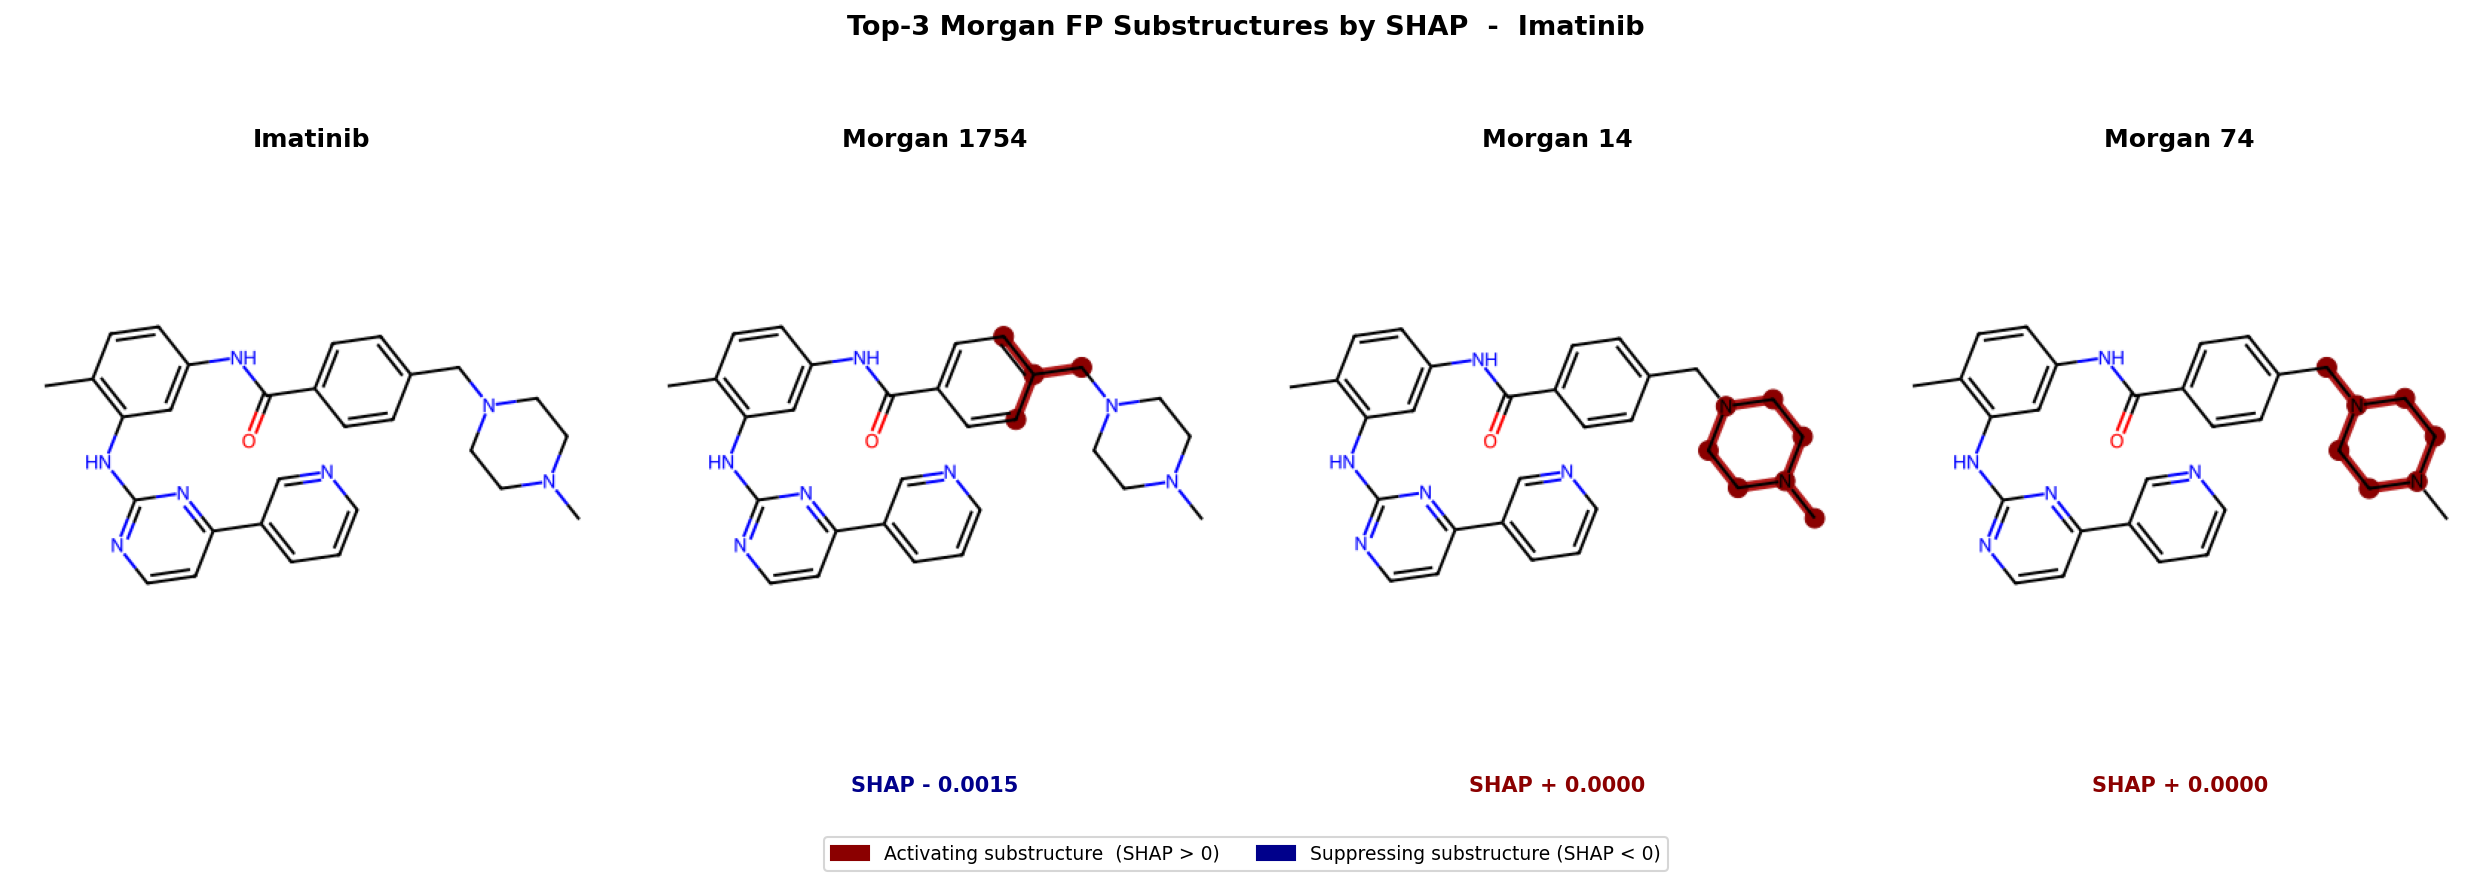

    Saved: /content/drive/MyDrive/models_new/shap_mol_Imatinib.png

  Neratinib
    1. Morgan   674  SHAP=-0.18880  (suppressing)
    2. Morgan   448  SHAP=-0.12439  (suppressing)
    3. Morgan    31  SHAP=+0.00000  (activating)


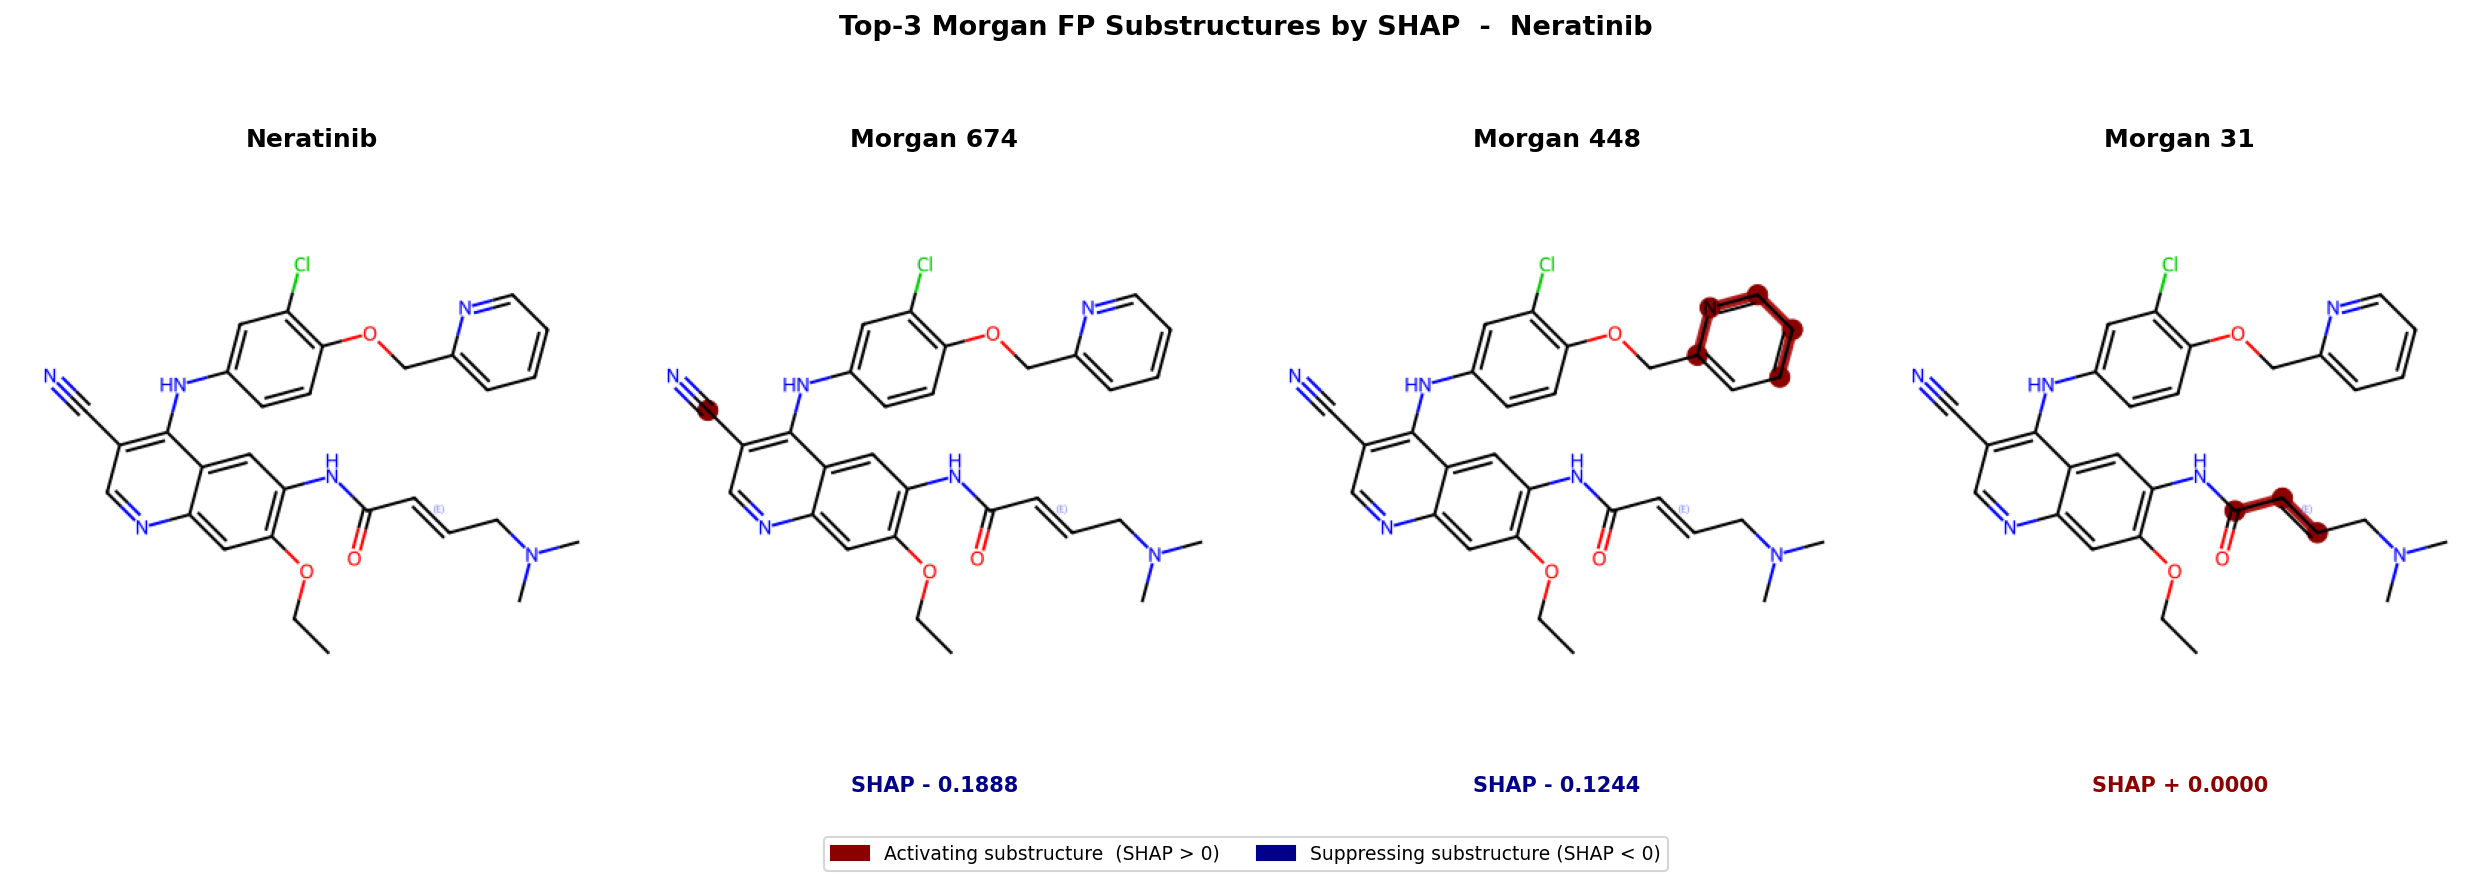

    Saved: /content/drive/MyDrive/models_new/shap_mol_Neratinib.png

  Sitagliptin
    1. Morgan  1934  SHAP=+0.51437  (activating)
    2. Morgan  1164  SHAP=+0.06747  (activating)
    3. Morgan     1  SHAP=+0.00000  (activating)


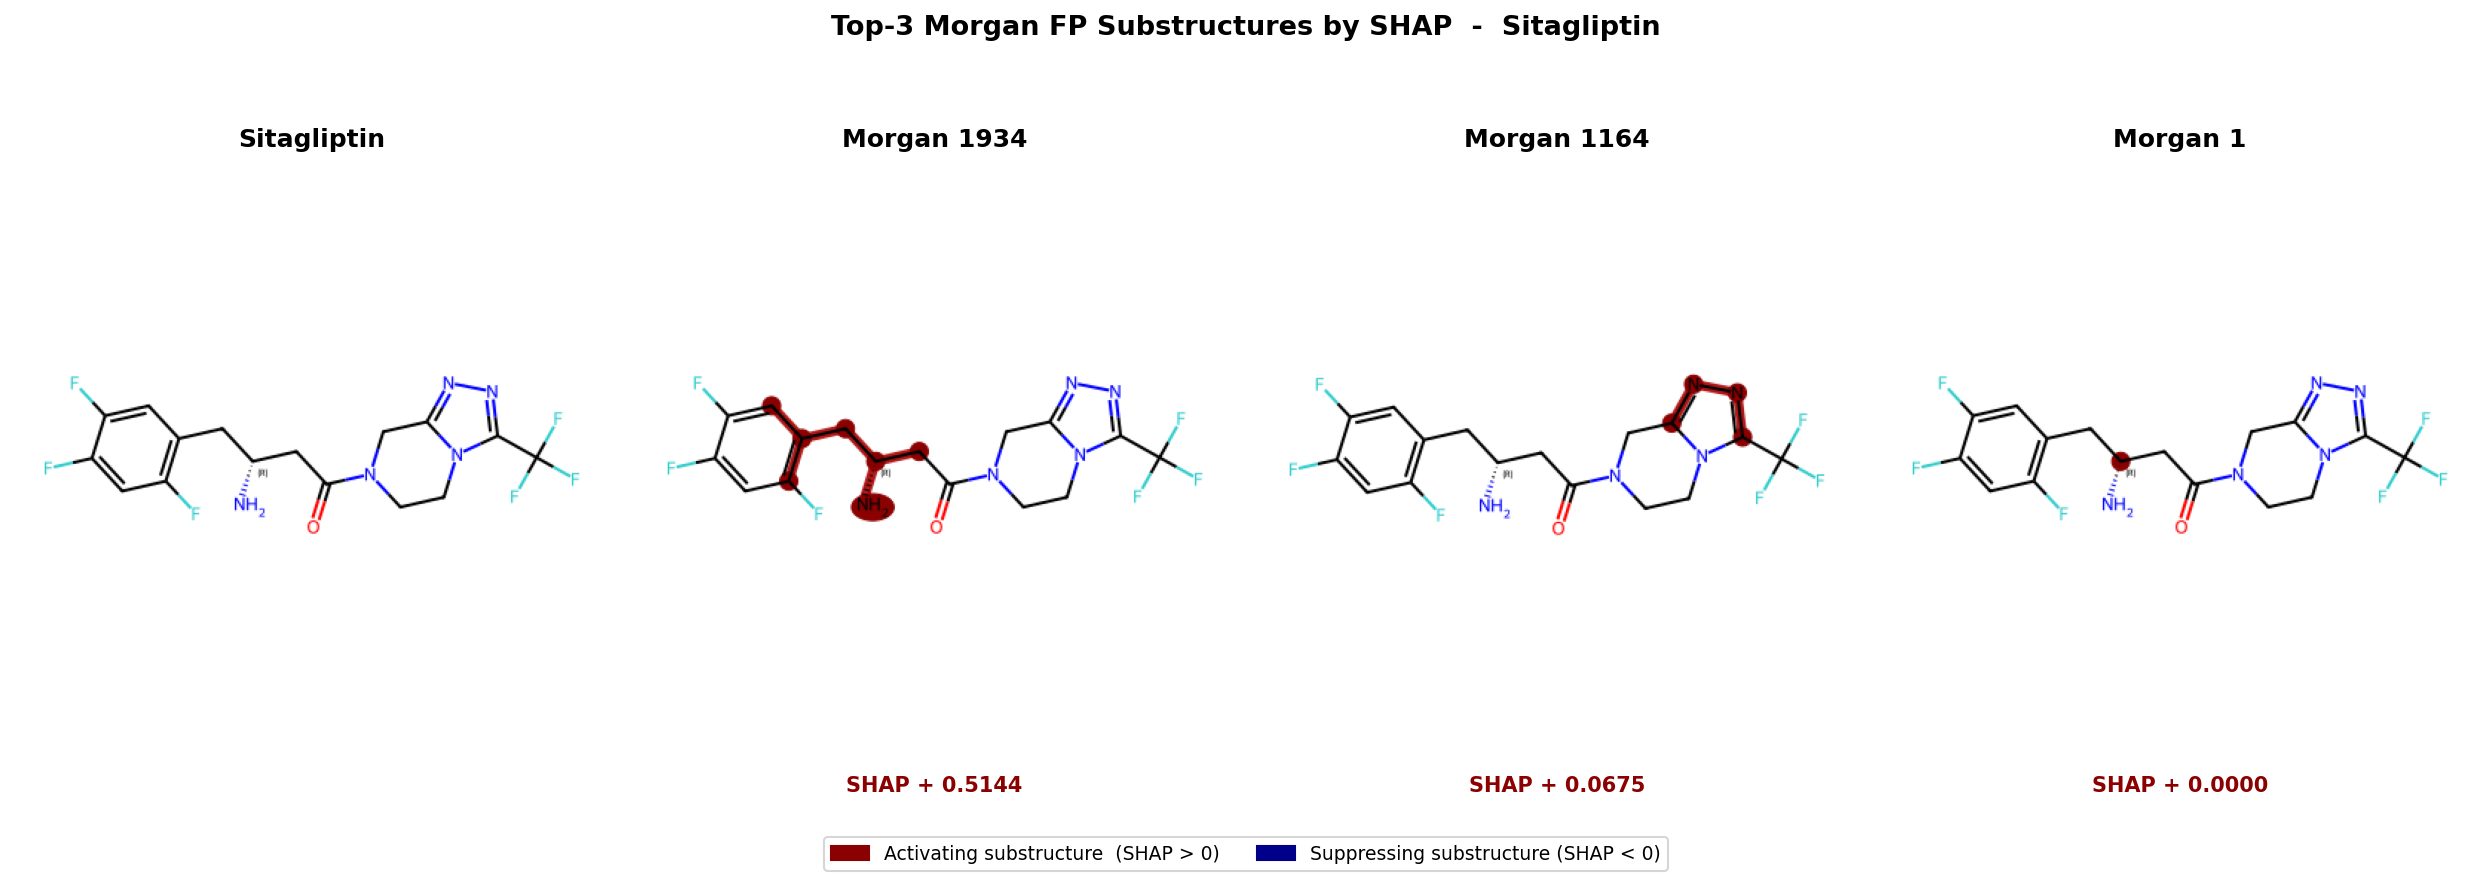

    Saved: /content/drive/MyDrive/models_new/shap_mol_Sitagliptin.png

  Sunitinib
    1. Morgan     8  SHAP=+0.00000  (activating)
    2. Morgan    74  SHAP=+0.00000  (activating)
    3. Morgan    80  SHAP=+0.00000  (activating)


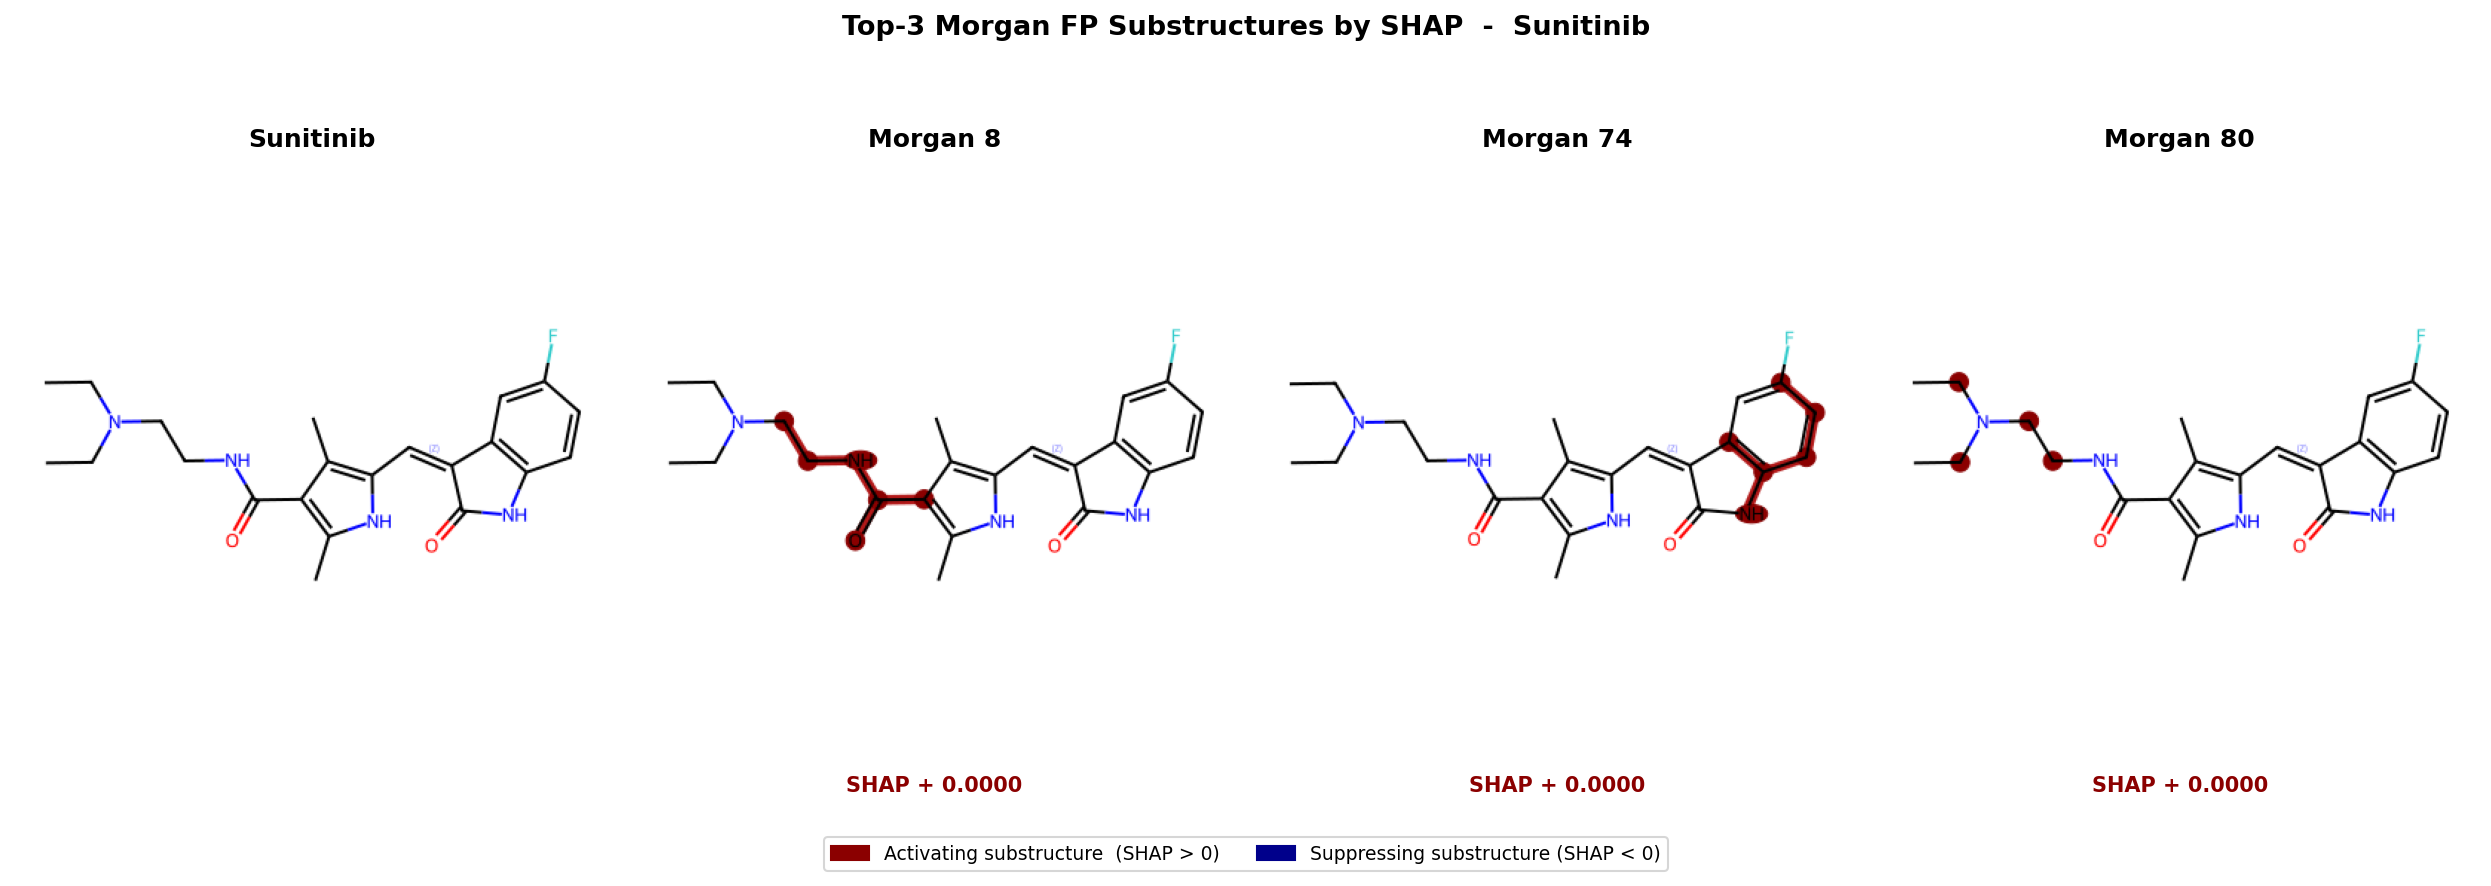

    Saved: /content/drive/MyDrive/models_new/shap_mol_Sunitinib.png

  Leucettinib-92
    1. Morgan    25  SHAP=+0.00000  (activating)
    2. Morgan    50  SHAP=+0.00000  (activating)
    3. Morgan   102  SHAP=+0.00000  (activating)


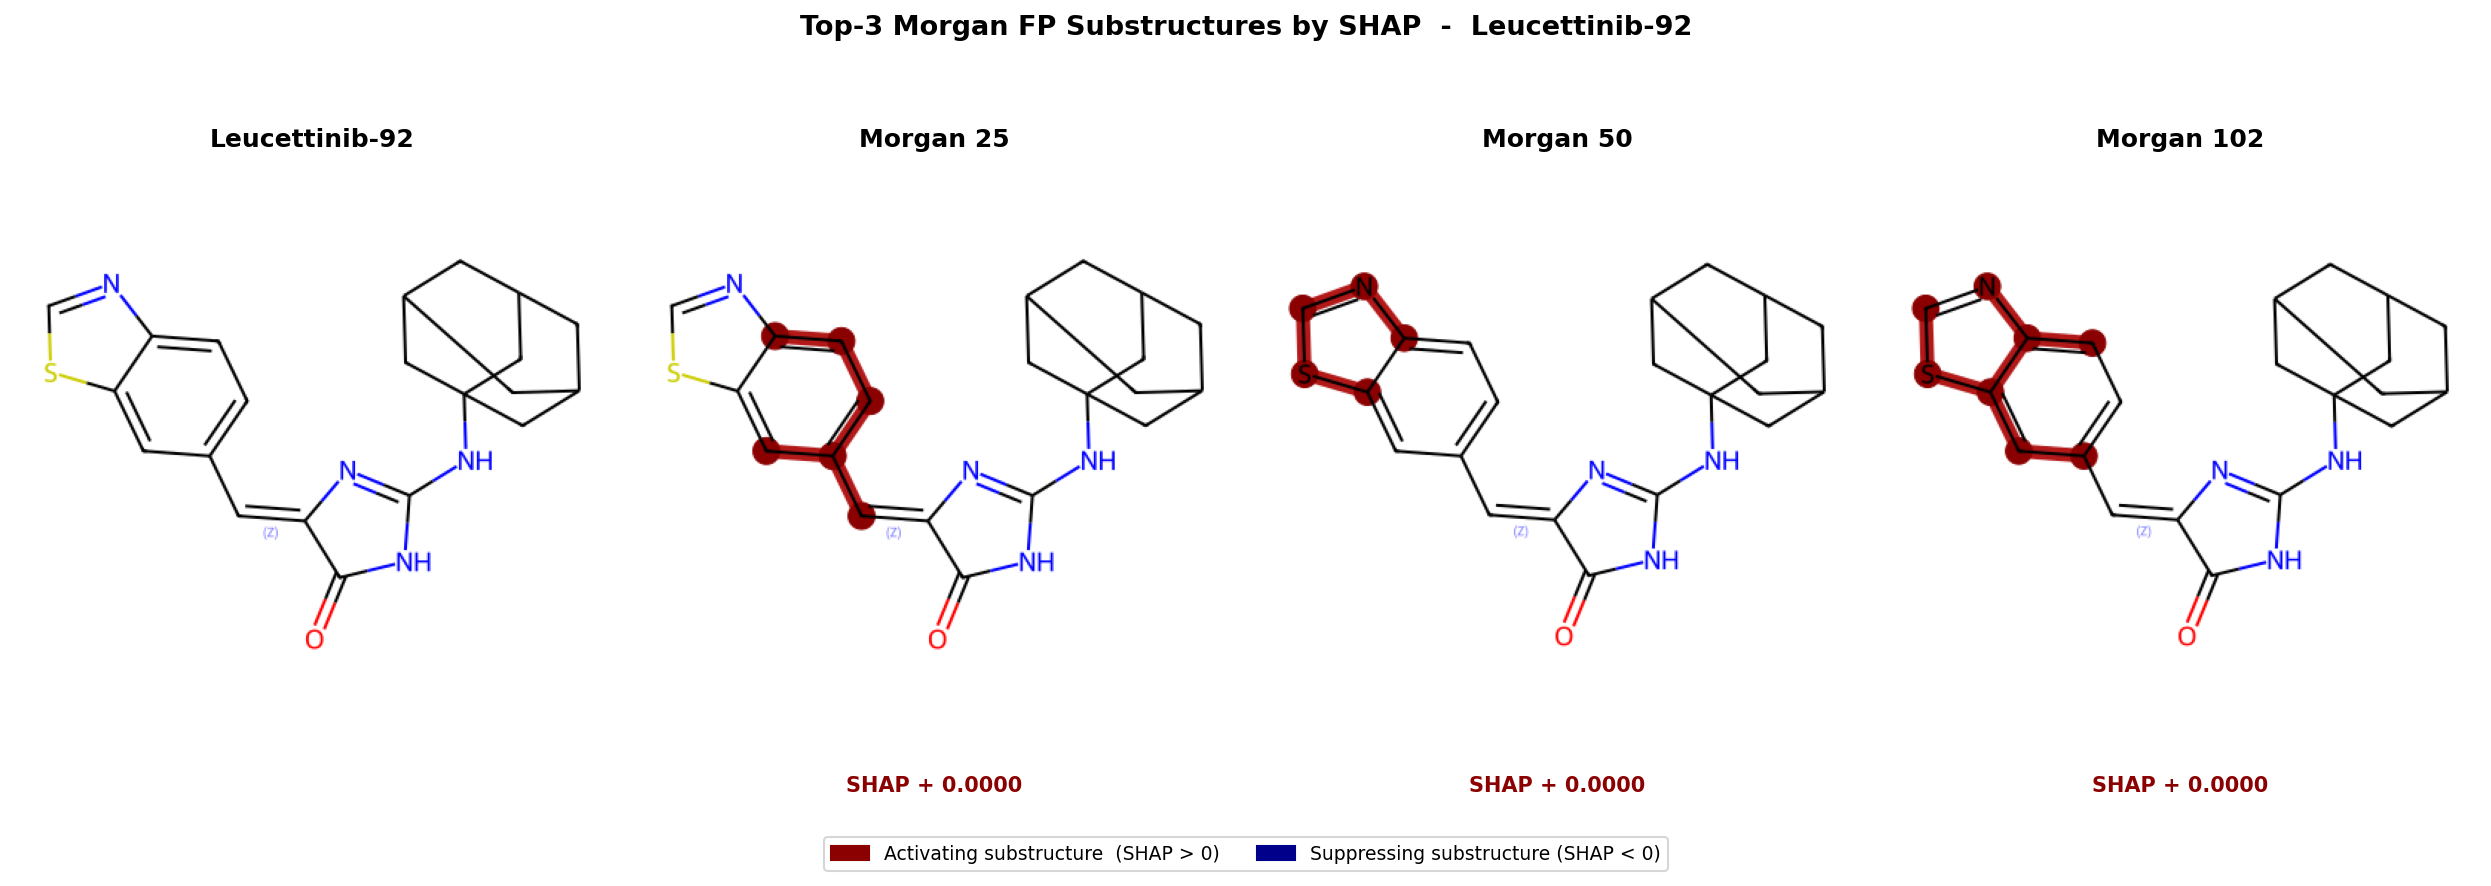

    Saved: /content/drive/MyDrive/models_new/shap_mol_Leucettinib-92.png

  Silmitasertib
    1. Morgan    72  SHAP=+0.00000  (activating)
    2. Morgan   160  SHAP=+0.00000  (activating)
    3. Morgan   165  SHAP=+0.00000  (activating)


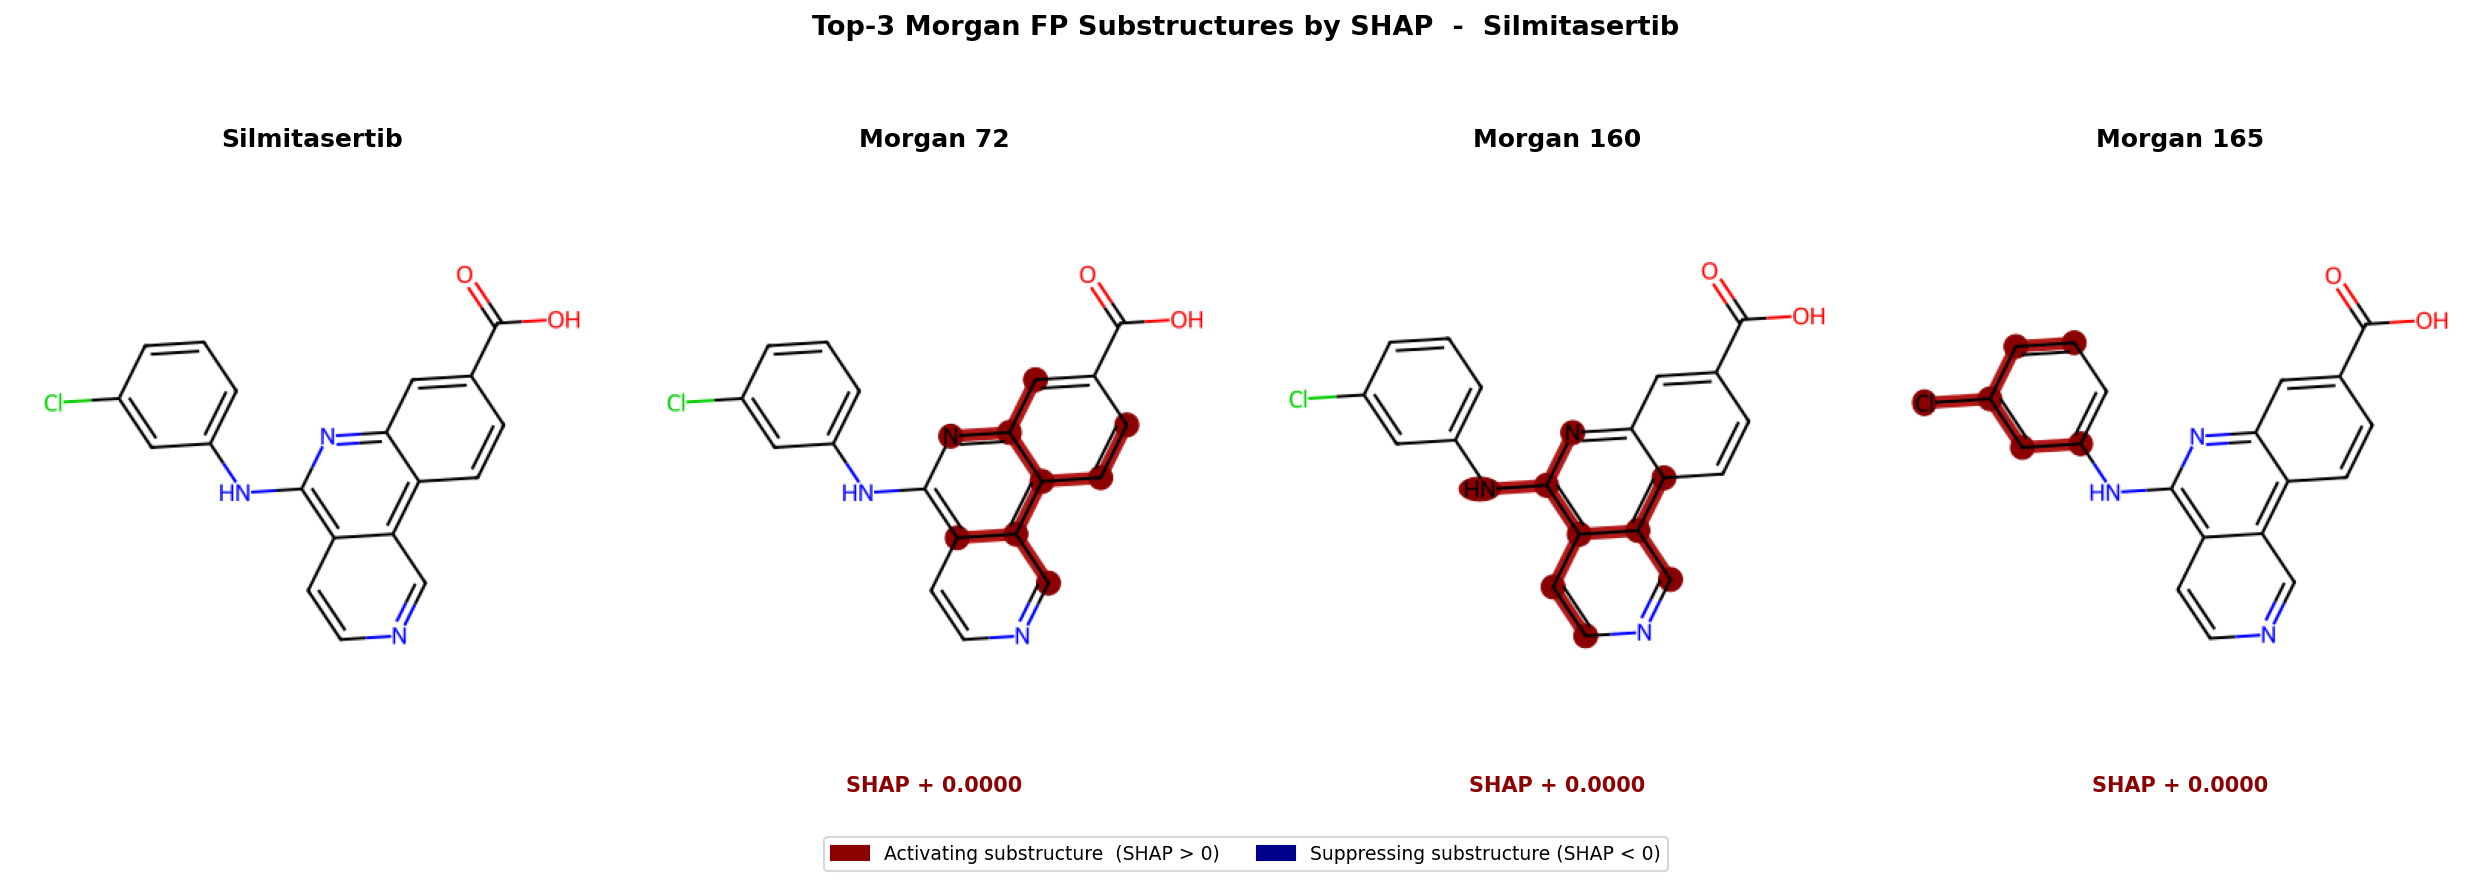

    Saved: /content/drive/MyDrive/models_new/shap_mol_Silmitasertib.png

ALL PER-MOLECULE SHAP PANELS COMPLETE


In [ ]:
# ================================================================
# 10. PER-MOLECULE SHAP FINGERPRINT PANEL
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from PIL import Image

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D

HIGHLIGHT_COLOR = (0.545, 0.0, 0.0)
BOND_COLOR      = (0.700, 0.1, 0.1)
IMG_SIZE        = 400


def _bit_number_from_name(feat_name, fallback):
    digits = "".join(c for c in feat_name if c.isdigit())
    return int(digits) if digits else fallback


def _render_mol(smiles, highlight_atoms=(), highlight_bonds=(), size=IMG_SIZE):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)

    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(size, size)
    except AttributeError:
        drawer = rdMolDraw2D.MolDraw2DSVG(size, size)

    opts = drawer.drawOptions()
    opts.addStereoAnnotation = True
    opts.addAtomIndices      = False

    atom_set = set(highlight_atoms)
    bond_set = set(highlight_bonds)

    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atom_set),
        highlightBonds=list(bond_set),
        highlightAtomColors={a: HIGHLIGHT_COLOR for a in atom_set},
        highlightBondColors={b: BOND_COLOR      for b in bond_set},
    )
    drawer.FinishDrawing()
    raw = drawer.GetDrawingText()
    try:
        return Image.open(BytesIO(raw)).convert("RGBA")
    except Exception:
        return None


def _atoms_and_bonds_for_bit(mol, bit_info, bit_num):
    atom_set = set()
    bond_set = set()
    if bit_num not in bit_info:
        return atom_set, bond_set
    for center_atom, radius in bit_info[bit_num]:
        atom_set.add(center_atom)
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom)
        for bond_idx in env:
            b = mol.GetBondWithIdx(bond_idx)
            atom_set.add(b.GetBeginAtomIdx())
            atom_set.add(b.GetEndAtomIdx())
            bond_set.add(bond_idx)
    return atom_set, bond_set


print("\n" + "="*70)
print("GENERATING PER-MOLECULE SHAP FINGERPRINT PANELS")
print("="*70)

for mol_data in viz_data:
    name      = mol_data["name"]
    smiles    = mol_data["smi"]
    shap_vals = mol_data["shap_fp_values"]
    bit_info  = mol_data["bit_info"]

    candidates = []
    for feat_idx, feat_name in enumerate(fp_feat_cols):
        bit_num = _bit_number_from_name(feat_name, feat_idx)
        if bit_num in bit_info:
            candidates.append((feat_idx, bit_num, shap_vals[feat_idx]))

    if not candidates:
        print(f"  X {name}: no active FP bits found - skipping")
        continue

    candidates.sort(key=lambda x: abs(x[2]), reverse=True)
    top3 = candidates[:3]

    print(f"\n  {name}")
    for rank, (fi, bn, sv) in enumerate(top3, 1):
        direction = "activating" if sv >= 0 else "suppressing"
        print(f"    {rank}. Morgan {bn:>5d}  SHAP={sv:+.5f}  ({direction})")

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"  X {name}: invalid SMILES")
        continue
    AllChem.Compute2DCoords(mol)

    panel_imgs   = [_render_mol(smiles)]
    panel_titles = [name]
    panel_shap   = [None]

    for feat_idx, bit_num, sv in top3:
        a_set, b_set = _atoms_and_bonds_for_bit(mol, bit_info, bit_num)
        img = _render_mol(smiles, highlight_atoms=a_set, highlight_bonds=b_set)
        panel_imgs.append(img)
        panel_titles.append(f"Morgan {bit_num}")
        panel_shap.append(sv)

    n_panels = len(panel_imgs)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(4.2 * n_panels, 5.2),
                             facecolor="white")
    if n_panels == 1:
        axes = [axes]

    for ax, img, title, sv in zip(axes, panel_imgs, panel_titles, panel_shap):
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14)
        ax.axis("off")
        ax.set_title(title, fontsize=12, fontweight="bold", pad=6)

        if sv is not None:
            colour = "#8B0000" if sv >= 0 else "#00008B"
            arrow  = "+" if sv >= 0 else "-"
            ax.text(0.5, -0.04,
                    f"SHAP {arrow} {abs(sv):.4f}",
                    transform=ax.transAxes,
                    ha="center", va="top",
                    fontsize=10, color=colour, fontweight="bold")

    legend_handles = [
        mpatches.Patch(color="#8B0000", label="Activating substructure  (SHAP > 0)"),
        mpatches.Patch(color="#00008B", label="Suppressing substructure (SHAP < 0)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))

    plt.suptitle(f"Top-3 Morgan FP Substructures by SHAP  -  {name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()

    fname = os.path.join(SAVE_DIR, f"shap_mol_{name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"    Saved: {fname}")

print("\n" + "="*70)
print("ALL PER-MOLECULE SHAP PANELS COMPLETE")
print("="*70)
